In [1]:
import random
import time

import tensorflow as tf
from tensorflow.keras import Sequential

from tensorflow.keras.layers import (
    Input,
    Conv1D,
    BatchNormalization,
    Activation,
    MaxPooling1D,
    Flatten,
    Dense,
    Dropout,
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix,  precision_score, recall_score, f1_score, accuracy_score,roc_auc_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler, Normalizer, OrdinalEncoder, MinMaxScaler,  LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.feature_selection import SelectKBest, chi2, SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

import numpy as np
import pandas as pd


In [2]:
train_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/DATASETS/KDDCUP99/train_kdd.csv",compression="infer") # 10% subset of the training data
test_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/DATASETS/KDDCUP99/test_kdd.csv", compression= "infer")

In [3]:
train_df.shape

(494021, 42)

# **An Intrusion Detection Model Based on Feature Reduction and Convolutional Neural Networks [72]**

Binary classification

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

In [ ]:
AE_EPOCHS = 20
CNN_EPOCHS = 50
BATCH_SIZE = 128

AE_LEARNING_RATE = 0.001  # Not specified; Adam default
CNN_LEARNING_RATE = 1e-4

DROPOUT_RATE = 0.30

NUMBER_OF_RAW_FEATURES = 41
NUMBER_OF_PROCESSED_FEATURES = 122
NUMBER_OF_REDUCED_FEATURES = 100
NUMBER_OF_CLASSES = 2

CLASS_NAMES = [
    "Normal",
    "Attack",
]

In [ ]:
feature_columns = [
    "duration",
    "protocol_type",
    "service",
    "flag",
    "src_bytes",
    "dst_bytes",
    "land",
    "wrong_fragment",
    "urgent",
    "hot",
    "num_failed_logins",
    "logged_in",
    "num_compromised",
    "root_shell",
    "su_attempted",
    "num_root",
    "num_file_creations",
    "num_shells",
    "num_access_files",
    "num_outbound_cmds",
    "is_host_login",
    "is_guest_login",
    "count",
    "srv_count",
    "serror_rate",
    "srv_serror_rate",
    "rerror_rate",
    "srv_rerror_rate",
    "same_srv_rate",
    "diff_srv_rate",
    "srv_diff_host_rate",
    "dst_host_count",
    "dst_host_srv_count",
    "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate",
    "dst_host_srv_serror_rate",
    "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate",
]

column_names = feature_columns + ["label"]

categorical_columns = [
    "protocol_type",
    "service",
    "flag",
]

numerical_columns = [
    column
    for column in feature_columns
    if column not in categorical_columns
]

print("Numerical features:", len(numerical_columns))
print("Categorical features:", len(categorical_columns))

Numerical features: 38
Categorical features: 3


In [ ]:
print("Training data shape:", train_df.shape)
print("Testing data shape: ", test_df.shape)

print(train_df.head())

Training data shape: (494021, 42)
Testing data shape:  (311029, 42)
   duration protocol_type service flag  src_bytes  dst_bytes  land  \
0         0           tcp    http   SF        181       5450     0   
1         0           tcp    http   SF        239        486     0   
2         0           tcp    http   SF        235       1337     0   
3         0           tcp    http   SF        219       1337     0   
4         0           tcp    http   SF        217       2032     0   

   wrong_fragment  urgent  hot  ...  dst_host_srv_count  \
0               0       0    0  ...                   9   
1               0       0    0  ...                  19   
2               0       0    0  ...                  29   
3               0       0    0  ...                  39   
4               0       0    0  ...                  49   

   dst_host_same_srv_rate  dst_host_diff_srv_rate  \
0                     1.0                     0.0   
1                     1.0                     0.0 

In [ ]:
train_labels = (
    train_df["outcome"]
    .astype(str)
    .str.strip()
    .str.rstrip(".")
    .str.lower()
)

test_labels = (
    test_df["outcome"]
    .astype(str)
    .str.strip()
    .str.rstrip(".")
    .str.lower()
)


# Binary target:
# 0 = normal
# 1 = any attack

y_train = (
    train_labels != "normal"
).astype(np.int32).to_numpy()

y_test = (
    test_labels != "normal"
).astype(np.int32).to_numpy()


print("Training target values:", np.unique(y_train))
print("Testing target values: ", np.unique(y_test))

Training target values: [0 1]
Testing target values:  [0 1]


In [ ]:
X_train_df = train_df[
    feature_columns
].copy()

X_test_df = test_df[
    feature_columns
].copy()


print("Training feature shape:", X_train_df.shape)
print("Testing feature shape: ", X_test_df.shape)

assert X_train_df.shape[1] == 41
assert X_test_df.shape[1] == 41

Training feature shape: (494021, 41)
Testing feature shape:  (311029, 41)


In [ ]:
train_normal_count = int(
    np.sum(y_train == 0)
)

train_attack_count = int(
    np.sum(y_train == 1)
)

test_normal_count = int(
    np.sum(y_test == 0)
)

test_attack_count = int(
    np.sum(y_test == 1)
)


print("KDD99 training distribution")
print("---------------------------")
print("Normal:", train_normal_count)
print("Attack:", train_attack_count)
print("Total: ", len(y_train))

print("\nCorrected test distribution")
print("---------------------------")
print("Normal:", test_normal_count)
print("Attack:", test_attack_count)
print("Total: ", len(y_test))

KDD99 training distribution
---------------------------
Normal: 97278
Attack: 396743
Total:  494021

Corrected test distribution
---------------------------
Normal: 60593
Attack: 250436
Total:  311029


In [ ]:
for column in categorical_columns:
    X_train_df[column] = (
        X_train_df[column]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    X_test_df[column] = (
        X_test_df[column]
        .astype(str)
        .str.strip()
        .str.lower()
    )

In [ ]:
for column in numerical_columns:
    X_train_df[column] = pd.to_numeric(
        X_train_df[column],
        errors="raise",
    ).astype(np.float32)

    X_test_df[column] = pd.to_numeric(
        X_test_df[column],
        errors="raise",
    ).astype(np.float32)

In [ ]:
protocol_categories = [
    "icmp",
    "tcp",
    "udp",
]


service_categories = [
    "aol",
    "auth",
    "bgp",
    "courier",
    "csnet_ns",
    "ctf",
    "daytime",
    "discard",
    "domain",
    "domain_u",
    "echo",
    "eco_i",
    "ecr_i",
    "efs",
    "exec",
    "finger",
    "ftp",
    "ftp_data",
    "gopher",
    "harvest",
    "hostnames",
    "http",
    "http_2784",
    "http_443",
    "http_8001",
    "imap4",
    "irc",
    "iso_tsap",
    "klogin",
    "kshell",
    "ldap",
    "link",
    "login",
    "mtp",
    "name",
    "netbios_dgm",
    "netbios_ns",
    "netbios_ssn",
    "netstat",
    "nnsp",
    "nntp",
    "ntp_u",
    "other",
    "pm_dump",
    "pop_2",
    "pop_3",
    "printer",
    "private",
    "red_i",
    "remote_job",
    "rje",
    "shell",
    "smtp",
    "sql_net",
    "ssh",
    "sunrpc",
    "supdup",
    "systat",
    "telnet",
    "tftp_u",
    "tim_i",
    "time",
    "urh_i",
    "urp_i",
    "uucp",
    "uucp_path",
    "vmnet",
    "whois",
    "x11",
    "z39_50",
]


flag_categories = [
    "oth",
    "rej",
    "rsto",
    "rstos0",
    "rstr",
    "s0",
    "s1",
    "s2",
    "s3",
    "sf",
    "sh",
]


print("Protocol categories:", len(protocol_categories))
print("Service categories: ", len(service_categories))
print("Flag categories:    ", len(flag_categories))

Protocol categories: 3
Service categories:  70
Flag categories:     11


In [ ]:
unknown_train_protocols = sorted(
    set(X_train_df["protocol_type"].unique())
    - set(protocol_categories)
)

unknown_test_protocols = sorted(
    set(X_test_df["protocol_type"].unique())
    - set(protocol_categories)
)


unknown_train_services = sorted(
    set(X_train_df["service"].unique())
    - set(service_categories)
)

unknown_test_services = sorted(
    set(X_test_df["service"].unique())
    - set(service_categories)
)


unknown_train_flags = sorted(
    set(X_train_df["flag"].unique())
    - set(flag_categories)
)

unknown_test_flags = sorted(
    set(X_test_df["flag"].unique())
    - set(flag_categories)
)


print("Unknown training protocols:", unknown_train_protocols)
print("Unknown testing protocols: ", unknown_test_protocols)

print("Unknown training services:", unknown_train_services)
print("Unknown testing services: ", unknown_test_services)

print("Unknown training flags:", unknown_train_flags)
print("Unknown testing flags: ", unknown_test_flags)

Unknown training protocols: []
Unknown testing protocols:  []
Unknown training services: []
Unknown testing services:  ['icmp']
Unknown training flags: []
Unknown testing flags:  []


In [ ]:
one_hot_encoder = OneHotEncoder(
    categories=[
        protocol_categories,
        service_categories,
        flag_categories,
    ],
    handle_unknown="ignore",
    sparse_output=False,
    dtype=np.float32,
)

In [ ]:
min_max_scaler = MinMaxScaler(
        feature_range=(0.0, 1.0),
        clip=True,
    )

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            min_max_scaler,
            numerical_columns,
        ),
        (
            "categorical",
            one_hot_encoder,
            categorical_columns,
        ),
    ],
    remainder="drop",
    sparse_threshold=0.0,
)

In [ ]:
X_train_processed = preprocessor.fit_transform(
    X_train_df
).astype(np.float32)

X_test_processed = preprocessor.transform(
    X_test_df
).astype(np.float32)


In [ ]:
processed_feature_names = (
    preprocessor.get_feature_names_out()
)

print(
    "Number of processed features:",
    len(processed_feature_names),
)

print("\nFirst 20 processed features:")
print(processed_feature_names[:20])

Number of processed features: 122

First 20 processed features:
['numerical__duration' 'numerical__src_bytes' 'numerical__dst_bytes'
 'numerical__land' 'numerical__wrong_fragment' 'numerical__urgent'
 'numerical__hot' 'numerical__num_failed_logins' 'numerical__logged_in'
 'numerical__num_compromised' 'numerical__root_shell'
 'numerical__su_attempted' 'numerical__num_root'
 'numerical__num_file_creations' 'numerical__num_shells'
 'numerical__num_access_files' 'numerical__num_outbound_cmds'
 'numerical__is_host_login' 'numerical__is_guest_login' 'numerical__count']


In [ ]:
tf.keras.backend.clear_session()


autoencoder = tf.keras.Sequential(
    [
        tf.keras.layers.Input(
            shape=(122,),
            name="autoencoder_input",
        ),

        tf.keras.layers.Dense(
            units=100,
            activation="relu",
            kernel_initializer=tf.keras.initializers.RandomNormal(
                mean=0.0,
                stddev=0.05,
            ),
            bias_initializer=tf.keras.initializers.RandomNormal(
                mean=0.0,
                stddev=0.05,
            ),
            name="bottleneck_100",
        ),

        tf.keras.layers.Dense(
            units=122,
            activation="sigmoid",
            kernel_initializer=tf.keras.initializers.RandomNormal(
                mean=0.0,
                stddev=0.05,
            ),
            bias_initializer=tf.keras.initializers.RandomNormal(
                mean=0.0,
                stddev=0.05,
            ),
            name="reconstruction_output",
        ),
    ],
    name="kdd99_ae_100",
)


autoencoder.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=AE_LEARNING_RATE,
    ),
    loss=tf.keras.losses.MeanSquaredError(),
)


autoencoder.summary()

Model: "kdd99_ae_100"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bottleneck_100 (Dense)          │ (None, 100)            │        12,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction_output (Dense)   │ (None, 122)            │        12,322 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,622 (96.18 KB)

 Trainable params: 24,622 (96.18 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
ae_history = autoencoder.fit(
    X_train_processed,
    X_train_processed,
    epochs=AE_EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    verbose=2,
)

Epoch 1/20
3860/3860 - 21s - 6ms/step - loss: 0.0029
Epoch 2/20
3860/3860 - 6s - 2ms/step - loss: 1.6150e-04
Epoch 3/20
3860/3860 - 6s - 2ms/step - loss: 1.1960e-04
Epoch 4/20
3860/3860 - 6s - 2ms/step - loss: 8.1178e-05
Epoch 5/20
3860/3860 - 6s - 2ms/step - loss: 4.3529e-05
Epoch 6/20
3860/3860 - 6s - 2ms/step - loss: 2.4144e-05
Epoch 7/20
3860/3860 - 6s - 2ms/step - loss: 1.9834e-05
Epoch 8/20
3860/3860 - 6s - 2ms/step - loss: 1.8040e-05
Epoch 9/20
3860/3860 - 6s - 2ms/step - loss: 1.6561e-05
Epoch 10/20
3860/3860 - 6s - 2ms/step - loss: 1.5198e-05
Epoch 11/20
3860/3860 - 6s - 2ms/step - loss: 1.4020e-05
Epoch 12/20
3860/3860 - 6s - 2ms/step - loss: 1.3193e-05
Epoch 13/20
3860/3860 - 6s - 2ms/step - loss: 1.2590e-05
Epoch 14/20
3860/3860 - 6s - 2ms/step - loss: 1.2069e-05
Epoch 15/20
3860/3860 - 6s - 2ms/step - loss: 1.1604e-05
Epoch 16/20
3860/3860 - 6s - 2ms/step - loss: 1.1113e-05
Epoch 17/20
3860/3860 - 6s - 2ms/step - loss: 1.0545e-05
Epoch 18/20
3860/3860 - 6s - 2ms/step - los

In [ ]:
_ = autoencoder(
    tf.zeros(
        shape=(1, 122),
        dtype=tf.float32,
    )
)

encoder = tf.keras.Model(
    inputs=autoencoder.inputs,
    outputs=autoencoder.get_layer(
        "bottleneck_100"
    ).output,
    name="kdd99_encoder_100",
)

encoder.summary()

Model: "kdd99_encoder_100"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ autoencoder_input (InputLayer)  │ (None, 122)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck_100 (Dense)          │ (None, 100)            │        12,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,300 (48.05 KB)

 Trainable params: 12,300 (48.05 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
X_train_reduced = encoder.predict(
    X_train_processed,
    batch_size=1024,
    verbose=1,
).astype(np.float32)

X_test_reduced = encoder.predict(
    X_test_processed,
    batch_size=1024,
    verbose=1,
).astype(np.float32)

print("Reduced training shape:", X_train_reduced.shape)
print("Reduced testing shape: ", X_test_reduced.shape)

assert X_train_reduced.shape[1] == 100
assert X_test_reduced.shape[1] == 100

483/483 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
304/304 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Reduced training shape: (494021, 100)
Reduced testing shape:  (311029, 100)


In [ ]:
X_train_images = X_train_reduced.reshape(
    -1,
    10,
    10,
    1,
)

X_test_images = X_test_reduced.reshape(
    -1,
    10,
    10,
    1,
)


print("CNN training input:", X_train_images.shape)
print("CNN testing input: ", X_test_images.shape)

CNN training input: (494021, 10, 10, 1)
CNN testing input:  (311029, 10, 10, 1)


In [ ]:
cnn_model = tf.keras.Sequential(
    [
        tf.keras.layers.Input(
            shape=(10, 10, 1),
            name="cnn_input",
        ),

        tf.keras.layers.Conv2D(
            filters=8,
            kernel_size=(2, 2),
            strides=(1, 1),
            padding="same",
            kernel_initializer=tf.keras.initializers.RandomNormal(
                mean=0.0,
                stddev=0.05,
            ),
            bias_initializer=tf.keras.initializers.RandomNormal(
                mean=0.0,
                stddev=0.05,
            ),
            name="conv_1",
        ),

        tf.keras.layers.BatchNormalization(
            name="batch_norm_1",
        ),

        tf.keras.layers.Activation(
            "relu",
            name="relu_1",
        ),

        tf.keras.layers.MaxPooling2D(
            pool_size=(2, 2),
            strides=(1, 1),
            padding="valid",
            name="max_pool_1",
        ),

        tf.keras.layers.Activation(
            "relu",
            name="pool_relu_1",
        ),

        tf.keras.layers.Conv2D(
            filters=16,
            kernel_size=(2, 2),
            strides=(1, 1),
            padding="same",
            kernel_initializer=tf.keras.initializers.RandomNormal(
                mean=0.0,
                stddev=0.05,
            ),
            bias_initializer=tf.keras.initializers.RandomNormal(
                mean=0.0,
                stddev=0.05,
            ),
            name="conv_2",
        ),

        tf.keras.layers.Activation(
            "relu",
            name="relu_2",
        ),

        tf.keras.layers.MaxPooling2D(
            pool_size=(2, 2),
            strides=(1, 1),
            padding="valid",
            name="max_pool_2",
        ),

        tf.keras.layers.Activation(
            "relu",
            name="pool_relu_2",
        ),

        tf.keras.layers.Dropout(
            rate=DROPOUT_RATE,
            name="pool_dropout",
        ),

        tf.keras.layers.Flatten(
            name="flatten",
        ),

        tf.keras.layers.Dense(
            units=64,
            kernel_initializer=tf.keras.initializers.RandomNormal(
                mean=0.0,
                stddev=0.05,
            ),
            bias_initializer=tf.keras.initializers.RandomNormal(
                mean=0.0,
                stddev=0.05,
            ),
            name="dense_64",
        ),

        tf.keras.layers.Activation(
            "relu",
            name="dense_relu",
        ),

        tf.keras.layers.Dropout(
            rate=DROPOUT_RATE,
            name="dense_dropout",
        ),

        tf.keras.layers.Dense(
            units=2,
            activation="softmax",
            kernel_initializer=tf.keras.initializers.RandomNormal(
                mean=0.0,
                stddev=0.05,
            ),
            bias_initializer=tf.keras.initializers.RandomNormal(
                mean=0.0,
                stddev=0.05,
            ),
            name="binary_output",
        ),
    ],
    name="kdd99_binary_cnn_ids",
)


cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=CNN_LEARNING_RATE,
    ),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(
            name="accuracy",
        ),
    ],
)


cnn_model.summary()

Model: "kdd99_binary_cnn_ids"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 10, 10, 8)      │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_1                    │ (None, 10, 10, 8)      │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_1 (Activation)             │ (None, 10, 10, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_1 (MaxPooling2D)       │ (None, 9, 9, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_relu_1 (Activation)        │ (None, 9, 9, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 9, 9, 16)       │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_2 (Activation)             │ (None, 9, 9, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_2 (MaxPooling2D)       │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_relu_2 (Activation)        │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_dropout (Dropout)          │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_relu (Activation)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_dropout (Dropout)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ binary_output (Dense)           │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,330 (259.10 KB)

 Trainable params: 66,314 (259.04 KB)

 Non-trainable params: 16 (64.00 B)

In [ ]:
print(
    "Conv 1 output:",
    cnn_model.get_layer("conv_1").output.shape,
)

print(
    "Pool 1 output:",
    cnn_model.get_layer("max_pool_1").output.shape,
)

print(
    "Conv 2 output:",
    cnn_model.get_layer("conv_2").output.shape,
)

print(
    "Pool 2 output:",
    cnn_model.get_layer("max_pool_2").output.shape,
)

print(
    "Flatten output:",
    cnn_model.get_layer("flatten").output.shape,
)

Conv 1 output: (None, 10, 10, 8)
Pool 1 output: (None, 9, 9, 8)
Conv 2 output: (None, 9, 9, 16)
Pool 2 output: (None, 8, 8, 16)
Flatten output: (None, 1024)


In [ ]:
cnn_history = cnn_model.fit(
    X_train_images,
    y_train,
    epochs=CNN_EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    verbose=2,
)

Epoch 1/50
3860/3860 - 24s - 6ms/step - accuracy: 0.9848 - loss: 0.0454
Epoch 2/50
3860/3860 - 8s - 2ms/step - accuracy: 0.9944 - loss: 0.0158
Epoch 3/50
3860/3860 - 8s - 2ms/step - accuracy: 0.9965 - loss: 0.0100
Epoch 4/50
3860/3860 - 8s - 2ms/step - accuracy: 0.9976 - loss: 0.0074
Epoch 5/50
3860/3860 - 8s - 2ms/step - accuracy: 0.9981 - loss: 0.0062
Epoch 6/50
3860/3860 - 8s - 2ms/step - accuracy: 0.9984 - loss: 0.0053
Epoch 7/50
3860/3860 - 8s - 2ms/step - accuracy: 0.9986 - loss: 0.0048
Epoch 8/50
3860/3860 - 8s - 2ms/step - accuracy: 0.9987 - loss: 0.0043
Epoch 9/50
3860/3860 - 8s - 2ms/step - accuracy: 0.9988 - loss: 0.0040
Epoch 10/50
3860/3860 - 8s - 2ms/step - accuracy: 0.9988 - loss: 0.0037
Epoch 11/50
3860/3860 - 8s - 2ms/step - accuracy: 0.9989 - loss: 0.0035
Epoch 12/50
3860/3860 - 8s - 2ms/step - accuracy: 0.9989 - loss: 0.0034
Epoch 13/50
3860/3860 - 8s - 2ms/step - accuracy: 0.9990 - loss: 0.0033
Epoch 14/50
3860/3860 - 8s - 2ms/step - accuracy: 0.9991 - loss: 0.0031


In [ ]:
test_probabilities = cnn_model.predict(
    X_test_images,
    batch_size=BATCH_SIZE,
    verbose=1,
)


y_pred = np.argmax(
    test_probabilities,
    axis=1,
)



2430/2430 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step


In [ ]:
cm = confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = cm.ravel()

accuracy = accuracy_score(y_test, y_pred)

recall = recall_score(
    y_test,
    y_pred,
    pos_label=1,
    zero_division=0,
)

precision = precision_score(
    y_test,
    y_pred,
    pos_label=1,
    zero_division=0,
)



false_positive_rate = (
    fp / (fp + tn)
    if (fp + tn) > 0
    else 0.0
)

f1 = f1_score(
    y_test,
    y_pred,
    pos_label=1,
    zero_division=0,
)


print("Confusion matrix")
print("----------------")
print(cm)

print("\nAttack-class metrics")
print("--------------------")
print(f"Accuracy : {accuracy:.4f} "
      f"({accuracy * 100:.2f}%)")
print(f"Detection rate : {recall:.4f} "
      f"({recall * 100:.2f}%)")
print(f"Precision      : {precision:.4f} "
      f"({precision * 100:.2f}%)")
print(f"FPR            : {false_positive_rate:.4f} "
      f"({false_positive_rate * 100:.2f}%)")
print(f"F1 score       : {f1:.4f} "
      f"({f1 * 100:.2f}%)")

Confusion matrix
----------------
[[ 59587   1006]
 [ 21730 228706]]

Attack-class metrics
--------------------
Accuracy : 0.9269 (92.69%)
Detection rate : 0.9132 (91.32%)
Precision      : 0.9956 (99.56%)
FPR            : 0.0166 (1.66%)
F1 score       : 0.9526 (95.26%)


In [ ]:
cnn_model.save("/content/drive/MyDrive/Models_Table_7/CNN_Xiao.keras")

Multiclass classification

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

In [ ]:
AE_EPOCHS = 20
CNN_EPOCHS = 50
BATCH_SIZE = 128

AE_LEARNING_RATE = 0.001

CNN_LEARNING_RATE = 1e-4
DROPOUT_RATE = 0.30

NUMBER_OF_PROCESSED_FEATURES = 122
NUMBER_OF_REDUCED_FEATURES = 100
NUMBER_OF_CLASSES = 5


CLASS_NAMES = [
    "DoS",
    "Normal",
    "Probe",
    "R2L",
    "U2R",
]

CLASS_TO_INDEX = {
    "DoS": 0,
    "Normal": 1,
    "Probe": 2,
    "R2L": 3,
    "U2R": 4,
}


In [ ]:
feature_columns = [
    "duration",
    "protocol_type",
    "service",
    "flag",
    "src_bytes",
    "dst_bytes",
    "land",
    "wrong_fragment",
    "urgent",
    "hot",
    "num_failed_logins",
    "logged_in",
    "num_compromised",
    "root_shell",
    "su_attempted",
    "num_root",
    "num_file_creations",
    "num_shells",
    "num_access_files",
    "num_outbound_cmds",
    "is_host_login",
    "is_guest_login",
    "count",
    "srv_count",
    "serror_rate",
    "srv_serror_rate",
    "rerror_rate",
    "srv_rerror_rate",
    "same_srv_rate",
    "diff_srv_rate",
    "srv_diff_host_rate",
    "dst_host_count",
    "dst_host_srv_count",
    "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate",
    "dst_host_srv_serror_rate",
    "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate",
]

column_names = feature_columns + ["label"]

categorical_columns = [
    "protocol_type",
    "service",
    "flag",
]

numerical_columns = [
    column
    for column in feature_columns
    if column not in categorical_columns
]

print("Raw features:", len(feature_columns))
print("Numerical features:", len(numerical_columns))
print("Categorical features:", len(categorical_columns))

Raw features: 41
Numerical features: 38
Categorical features: 3


In [ ]:
expected_protocols = {
    "tcp",
    "udp",
    "icmp",
}



In [ ]:
train_df.columns = column_names
test_df.columns = column_names

train_df = train_df.copy()
test_df = test_df.copy()


print("Corrected training shape:", train_df.shape)
print("Corrected testing shape: ", test_df.shape)

print(train_df.head())

Corrected training shape: (494021, 42)
Corrected testing shape:  (311029, 42)
   duration protocol_type service flag  src_bytes  dst_bytes  land  \
0         0           tcp    http   SF        181       5450     0   
1         0           tcp    http   SF        239        486     0   
2         0           tcp    http   SF        235       1337     0   
3         0           tcp    http   SF        219       1337     0   
4         0           tcp    http   SF        217       2032     0   

   wrong_fragment  urgent  hot  ...  dst_host_srv_count  \
0               0       0    0  ...                   9   
1               0       0    0  ...                  19   
2               0       0    0  ...                  29   
3               0       0    0  ...                  39   
4               0       0    0  ...                  49   

   dst_host_same_srv_rate  dst_host_diff_srv_rate  \
0                     1.0                     0.0   
1                     1.0               

In [ ]:
for column in categorical_columns:

    print(f"\nTraining {column} values:")
    print(
        sorted(
            train_df[column]
            .astype(str)
            .str.strip()
            .str.lower()
            .unique()
        )[:20]
    )

    print(f"Testing {column} values:")
    print(
        sorted(
            test_df[column]
            .astype(str)
            .str.strip()
            .str.lower()
            .unique()
        )[:20]
    )


Training protocol_type values:
['icmp', 'tcp', 'udp']
Testing protocol_type values:
['icmp', 'tcp', 'udp']

Training service values:
['auth', 'bgp', 'courier', 'csnet_ns', 'ctf', 'daytime', 'discard', 'domain', 'domain_u', 'echo', 'eco_i', 'ecr_i', 'efs', 'exec', 'finger', 'ftp', 'ftp_data', 'gopher', 'hostnames', 'http']
Testing service values:
['auth', 'bgp', 'courier', 'csnet_ns', 'ctf', 'daytime', 'discard', 'domain', 'domain_u', 'echo', 'eco_i', 'ecr_i', 'efs', 'exec', 'finger', 'ftp', 'ftp_data', 'gopher', 'hostnames', 'http']

Training flag values:
['oth', 'rej', 'rsto', 'rstos0', 'rstr', 's0', 's1', 's2', 's3', 'sf', 'sh']
Testing flag values:
['oth', 'rej', 'rsto', 'rstos0', 'rstr', 's0', 's1', 's2', 's3', 'sf', 'sh']


In [ ]:
training_protocols = set(
    train_df["protocol_type"]
    .astype(str)
    .str.strip()
    .str.lower()
    .unique()
)

testing_protocols = set(
    test_df["protocol_type"]
    .astype(str)
    .str.strip()
    .str.lower()
    .unique()
)

In [ ]:
training_services = set(
    train_df["service"]
    .astype(str)
    .str.strip()
    .str.lower()
    .unique()
)

testing_services = set(
    test_df["service"]
    .astype(str)
    .str.strip()
    .str.lower()
    .unique()
)


In [ ]:
ATTACK_GROUPS = {
    "Normal": {
        "normal",
    },

    "DoS": {
        "apache2",
        "back",
        "land",
        "mailbomb",
        "neptune",
        "pod",
        "processtable",
        "smurf",
        "teardrop",
        "udpstorm",
    },

    "Probe": {
        "ipsweep",
        "mscan",
        "nmap",
        "portsweep",
        "saint",
        "satan",
    },

    "R2L": {
        "ftp_write",
        "guess_passwd",
        "imap",
        "multihop",
        "named",
        "phf",
        "sendmail",
        "snmpgetattack",
        "snmpguess",
        "spy",
        "warezclient",
        "warezmaster",
        "worm",
        "xlock",
        "xsnoop",
    },

    "U2R": {
        "buffer_overflow",
        "httptunnel",
        "loadmodule",
        "perl",
        "ps",
        "rootkit",
        "sqlattack",
        "xterm",
    },
}

In [ ]:
ATTACK_TO_CLASS = {
    attack_name: class_name
    for class_name, attack_names in ATTACK_GROUPS.items()
    for attack_name in attack_names
}

In [ ]:
train_attack_names = (
    train_df["label"]
    .astype(str)
    .str.strip()
    .str.rstrip(".")
    .str.lower()
)

test_attack_names = (
    test_df["label"]
    .astype(str)
    .str.strip()
    .str.rstrip(".")
    .str.lower()
)

In [ ]:
train_class_names = train_attack_names.map(
    ATTACK_TO_CLASS
)

test_class_names = test_attack_names.map(
    ATTACK_TO_CLASS
)


unknown_train_labels = sorted(
    train_attack_names[
        train_class_names.isna()
    ].unique()
)

unknown_test_labels = sorted(
    test_attack_names[
        test_class_names.isna()
    ].unique()
)


print("Unknown training labels:", unknown_train_labels)
print("Unknown testing labels: ", unknown_test_labels)


if unknown_train_labels:
    raise ValueError(
        "Unknown KDD99 training labels: "
        f"{unknown_train_labels}"
    )

if unknown_test_labels:
    raise ValueError(
        "Unknown KDD99 testing labels: "
        f"{unknown_test_labels}"
    )

Unknown training labels: []
Unknown testing labels:  []


In [ ]:
y_train = (
    train_class_names
    .map(CLASS_TO_INDEX)
    .to_numpy(dtype=np.int32)
)

y_test = (
    test_class_names
    .map(CLASS_TO_INDEX)
    .to_numpy(dtype=np.int32)
)


print("Training target values:", np.unique(y_train))
print("Testing target values: ", np.unique(y_test))

Training target values: [0 1 2 3 4]
Testing target values:  [0 1 2 3 4]


In [ ]:
for class_index, class_name in enumerate(CLASS_NAMES):

    class_count = int(
        np.sum(y_train == class_index)
    )

    class_percentage = (
        100.0 * class_count / len(y_train)
    )

    print(
        f"{class_name:7s}: "
        f"{class_count:7d} "
        f"({class_percentage:7.4f}%)"
    )


for class_index, class_name in enumerate(CLASS_NAMES):

    class_count = int(
        np.sum(y_test == class_index)
    )

    class_percentage = (
        100.0 * class_count / len(y_test)
    )

    print(
        f"{class_name:7s}: "
        f"{class_count:7d} "
        f"({class_percentage:7.4f}%)"
    )

DoS    :  391458 (79.2391%)
Normal :   97278 (19.6911%)
Probe  :    4107 ( 0.8313%)
R2L    :    1126 ( 0.2279%)
U2R    :      52 ( 0.0105%)
DoS    :  229853 (73.9008%)
Normal :   60593 (19.4815%)
Probe  :    4166 ( 1.3394%)
R2L    :   16189 ( 5.2050%)
U2R    :     228 ( 0.0733%)


In [ ]:
y_train_encoded = tf.keras.utils.to_categorical(
    y_train,
    num_classes=NUMBER_OF_CLASSES,
).astype(np.float32)

y_test_encoded = tf.keras.utils.to_categorical(
    y_test,
    num_classes=NUMBER_OF_CLASSES,
).astype(np.float32)


print("Encoded training labels:", y_train_encoded.shape)
print("Encoded testing labels: ", y_test_encoded.shape)

Encoded training labels: (494021, 5)
Encoded testing labels:  (311029, 5)


In [ ]:
X_train_df = train_df[
    feature_columns
].copy()

X_test_df = test_df[
    feature_columns
].copy()


print("Training feature shape:", X_train_df.shape)
print("Testing feature shape: ", X_test_df.shape)

assert X_train_df.shape[1] == 41
assert X_test_df.shape[1] == 41

Training feature shape: (494021, 41)
Testing feature shape:  (311029, 41)


In [ ]:
for column in categorical_columns:

    X_train_df[column] = (
        X_train_df[column]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    X_test_df[column] = (
        X_test_df[column]
        .astype(str)
        .str.strip()
        .str.lower()
    )


for column in numerical_columns:

    X_train_df[column] = pd.to_numeric(
        X_train_df[column],
        errors="raise",
    ).astype(np.float32)

    X_test_df[column] = pd.to_numeric(
        X_test_df[column],
        errors="raise",
    ).astype(np.float32)

In [ ]:
protocol_categories = [
    "tcp",
    "udp",
    "icmp",
]


service_categories = [
    "aol",
    "auth",
    "bgp",
    "courier",
    "csnet_ns",
    "ctf",
    "daytime",
    "discard",
    "domain",
    "domain_u",
    "echo",
    "eco_i",
    "ecr_i",
    "efs",
    "exec",
    "finger",
    "ftp",
    "ftp_data",
    "gopher",
    "harvest",
    "hostnames",
    "http",
    "http_2784",
    "http_443",
    "http_8001",
    "imap4",
    "irc",
    "iso_tsap",
    "klogin",
    "kshell",
    "ldap",
    "link",
    "login",
    "mtp",
    "name",
    "netbios_dgm",
    "netbios_ns",
    "netbios_ssn",
    "netstat",
    "nnsp",
    "nntp",
    "ntp_u",
    "other",
    "pm_dump",
    "pop_2",
    "pop_3",
    "printer",
    "private",
    "red_i",
    "remote_job",
    "rje",
    "shell",
    "smtp",
    "sql_net",
    "ssh",
    "sunrpc",
    "supdup",
    "systat",
    "telnet",
    "tftp_u",
    "tim_i",
    "time",
    "urh_i",
    "urp_i",
    "uucp",
    "uucp_path",
    "vmnet",
    "whois",
    "x11",
    "z39_50",
]


flag_categories = [
    "oth",
    "rej",
    "rsto",
    "rstos0",
    "rstr",
    "s0",
    "s1",
    "s2",
    "s3",
    "sf",
    "sh",
]


print("Protocol categories:", len(protocol_categories))
print("Service categories: ", len(service_categories))
print("Flag categories:    ", len(flag_categories))

assert len(protocol_categories) == 3
assert len(service_categories) == 70
assert len(flag_categories) == 11

Protocol categories: 3
Service categories:  70
Flag categories:     11


In [ ]:
one_hot_encoder = OneHotEncoder(
        categories=[
            protocol_categories,
            service_categories,
            flag_categories,
        ],
        handle_unknown="ignore",
        sparse_output=False,
        dtype=np.float32,
    )

min_max_scaler = MinMaxScaler(
        feature_range=(0.0, 1.0),
        clip=True,
    )


preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            min_max_scaler,
            numerical_columns,
        ),
        (
            "categorical",
            one_hot_encoder,
            categorical_columns,
        ),
    ],
    remainder="drop",
    sparse_threshold=0.0,
)

In [ ]:
X_train_processed = preprocessor.fit_transform(
    X_train_df
).astype(np.float32)

X_test_processed = preprocessor.transform(
    X_test_df
).astype(np.float32)


X_train_processed = np.clip(
    X_train_processed,
    0.0,
    1.0,
)

X_test_processed = np.clip(
    X_test_processed,
    0.0,
    1.0,
)

In [ ]:
processed_feature_names = (
    preprocessor.get_feature_names_out()
)


autoencoder_input = tf.keras.layers.Input(
    shape=(122,),
    name="autoencoder_input",
)

bottleneck_output = tf.keras.layers.Dense(
    units=100,
    activation="relu",
    kernel_initializer=tf.keras.initializers.RandomNormal(
        mean=0.0,
        stddev=0.05,
        seed=SEED + 1,
    ),
    bias_initializer=tf.keras.initializers.RandomNormal(
        mean=0.0,
        stddev=0.05,
        seed=SEED + 2,
    ),
    name="bottleneck_100",
)(
    autoencoder_input
)

In [ ]:
reconstruction_output = tf.keras.layers.Dense(
    units=122,
    activation="sigmoid",
    kernel_initializer=tf.keras.initializers.RandomNormal(
        mean=0.0,
        stddev=0.05,
        seed=SEED + 3,
    ),
    bias_initializer=tf.keras.initializers.RandomNormal(
        mean=0.0,
        stddev=0.05,
        seed=SEED + 4,
    ),
    name="reconstruction_output",
)(
    bottleneck_output
)

In [ ]:
autoencoder = tf.keras.Model(
    inputs=autoencoder_input,
    outputs=reconstruction_output,
    name="kdd99_autoencoder_100",
)

encoder = tf.keras.Model(
    inputs=autoencoder_input,
    outputs=bottleneck_output,
    name="kdd99_encoder_100",
)

autoencoder.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=AE_LEARNING_RATE,
    ),
    loss=tf.keras.losses.MeanSquaredError(),
)


autoencoder.summary()
encoder.summary()

Model: "kdd99_autoencoder_100"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ autoencoder_input (InputLayer)  │ (None, 122)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck_100 (Dense)          │ (None, 100)            │        12,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction_output (Dense)   │ (None, 122)            │        12,322 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,622 (96.18 KB)

 Trainable params: 24,622 (96.18 KB)

 Non-trainable params: 0 (0.00 B)

Model: "kdd99_encoder_100"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ autoencoder_input (InputLayer)  │ (None, 122)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck_100 (Dense)          │ (None, 100)            │        12,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,300 (48.05 KB)

 Trainable params: 12,300 (48.05 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
ae_history = autoencoder.fit(
    X_train_processed,
    X_train_processed,
    epochs=AE_EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    verbose=2,
)

Epoch 1/20
3860/3860 - 23s - 6ms/step - loss: 0.0030
Epoch 2/20
3860/3860 - 7s - 2ms/step - loss: 1.7877e-04
Epoch 3/20
3860/3860 - 6s - 2ms/step - loss: 1.3391e-04
Epoch 4/20
3860/3860 - 6s - 2ms/step - loss: 9.0926e-05
Epoch 5/20
3860/3860 - 6s - 2ms/step - loss: 5.1462e-05
Epoch 6/20
3860/3860 - 6s - 2ms/step - loss: 3.0917e-05
Epoch 7/20
3860/3860 - 7s - 2ms/step - loss: 2.5310e-05
Epoch 8/20
3860/3860 - 6s - 2ms/step - loss: 2.2857e-05
Epoch 9/20
3860/3860 - 7s - 2ms/step - loss: 1.9509e-05
Epoch 10/20
3860/3860 - 6s - 2ms/step - loss: 1.7737e-05
Epoch 11/20
3860/3860 - 6s - 2ms/step - loss: 1.6568e-05
Epoch 12/20
3860/3860 - 6s - 2ms/step - loss: 1.5620e-05
Epoch 13/20
3860/3860 - 6s - 2ms/step - loss: 1.4708e-05
Epoch 14/20
3860/3860 - 6s - 2ms/step - loss: 1.3747e-05
Epoch 15/20
3860/3860 - 6s - 2ms/step - loss: 1.2899e-05
Epoch 16/20
3860/3860 - 7s - 2ms/step - loss: 1.2141e-05
Epoch 17/20
3860/3860 - 7s - 2ms/step - loss: 1.1450e-05
Epoch 18/20
3860/3860 - 6s - 2ms/step - los

In [ ]:
X_train_reduced = encoder.predict(
    X_train_processed,
    batch_size=1024,
    verbose=1,
).astype(np.float32)

X_test_reduced = encoder.predict(
    X_test_processed,
    batch_size=1024,
    verbose=1,
).astype(np.float32)


print("Reduced training shape:", X_train_reduced.shape)
print("Reduced testing shape: ", X_test_reduced.shape)

483/483 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
304/304 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
Reduced training shape: (494021, 100)
Reduced testing shape:  (311029, 100)


In [ ]:
X_train_images = X_train_reduced.reshape(
    -1,
    10,
    10,
    1,
)

X_test_images = X_test_reduced.reshape(
    -1,
    10,
    10,
    1,
)

In [ ]:
cnn_model = tf.keras.Sequential(
    [
        tf.keras.layers.Input(
            shape=(10, 10, 1),
            name="cnn_input",
        ),

        tf.keras.layers.Conv2D(
            filters=8,
            kernel_size=(2, 2),
            strides=(1, 1),
            padding="same",
            kernel_initializer=tf.keras.initializers.RandomNormal(
                mean=0.0,
                stddev=0.05,
                seed=SEED + 10,
            ),
            bias_initializer=tf.keras.initializers.RandomNormal(
                mean=0.0,
                stddev=0.05,
                seed=SEED + 11,
            ),
            name="conv_1",
        ),

        tf.keras.layers.BatchNormalization(
            name="batch_norm_1",
        ),

        tf.keras.layers.Activation(
            "relu",
            name="conv_relu_1",
        ),

        tf.keras.layers.MaxPooling2D(
            pool_size=(2, 2),
            strides=(1, 1),
            padding="valid",
            name="max_pool_1",
        ),

        tf.keras.layers.Activation(
            "relu",
            name="pool_relu_1",
        ),

        tf.keras.layers.Conv2D(
            filters=16,
            kernel_size=(2, 2),
            strides=(1, 1),
            padding="same",
            kernel_initializer=tf.keras.initializers.RandomNormal(
                mean=0.0,
                stddev=0.05,
                seed=SEED + 12,
            ),
            bias_initializer=tf.keras.initializers.RandomNormal(
                mean=0.0,
                stddev=0.05,
                seed=SEED + 13,
            ),
            name="conv_2",
        ),

        tf.keras.layers.Activation(
            "relu",
            name="conv_relu_2",
        ),

        tf.keras.layers.MaxPooling2D(
            pool_size=(2, 2),
            strides=(1, 1),
            padding="valid",
            name="max_pool_2",
        ),

        tf.keras.layers.Activation(
            "relu",
            name="pool_relu_2",
        ),

        tf.keras.layers.Dropout(
            rate=DROPOUT_RATE,
            name="pool_dropout",
        ),

        tf.keras.layers.Flatten(
            name="flatten",
        ),

        tf.keras.layers.Dense(
            units=64,
            kernel_initializer=tf.keras.initializers.RandomNormal(
                mean=0.0,
                stddev=0.05,
                seed=SEED + 14,
            ),
            bias_initializer=tf.keras.initializers.RandomNormal(
                mean=0.0,
                stddev=0.05,
                seed=SEED + 15,
            ),
            name="dense_64",
        ),

        tf.keras.layers.Activation(
            "relu",
            name="dense_relu",
        ),

        tf.keras.layers.Dropout(
            rate=DROPOUT_RATE,
            name="dense_dropout",
        ),

        tf.keras.layers.Dense(
            units=5,
            activation="softmax",
            kernel_initializer=tf.keras.initializers.RandomNormal(
                mean=0.0,
                stddev=0.05,
                seed=SEED + 16,
            ),
            bias_initializer=tf.keras.initializers.RandomNormal(
                mean=0.0,
                stddev=0.05,
                seed=SEED + 17,
            ),
            name="multiclass_output",
        ),
    ],
    name="kdd99_multiclass_cnn_ids",
)

In [ ]:
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=CNN_LEARNING_RATE,
    ),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=[
        tf.keras.metrics.CategoricalAccuracy(
            name="accuracy",
        ),
    ],
)


cnn_model.summary()

Model: "kdd99_multiclass_cnn_ids"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 10, 10, 8)      │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_1                    │ (None, 10, 10, 8)      │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_relu_1 (Activation)        │ (None, 10, 10, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_1 (MaxPooling2D)       │ (None, 9, 9, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_relu_1 (Activation)        │ (None, 9, 9, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 9, 9, 16)       │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_relu_2 (Activation)        │ (None, 9, 9, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_2 (MaxPooling2D)       │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_relu_2 (Activation)        │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_dropout (Dropout)          │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_relu (Activation)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_dropout (Dropout)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiclass_output (Dense)       │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,525 (259.86 KB)

 Trainable params: 66,509 (259.80 KB)

 Non-trainable params: 16 (64.00 B)

In [ ]:
cnn_history = cnn_model.fit(
    X_train_images,
    y_train_encoded,
    epochs=CNN_EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    verbose=2,
)

Epoch 1/50
3860/3860 - 24s - 6ms/step - accuracy: 0.9795 - loss: 0.0789
Epoch 2/50
3860/3860 - 8s - 2ms/step - accuracy: 0.9922 - loss: 0.0270
Epoch 3/50
3860/3860 - 9s - 2ms/step - accuracy: 0.9935 - loss: 0.0194
Epoch 4/50
3860/3860 - 9s - 2ms/step - accuracy: 0.9954 - loss: 0.0133
Epoch 5/50
3860/3860 - 8s - 2ms/step - accuracy: 0.9969 - loss: 0.0097
Epoch 6/50
3860/3860 - 8s - 2ms/step - accuracy: 0.9976 - loss: 0.0078
Epoch 7/50
3860/3860 - 8s - 2ms/step - accuracy: 0.9981 - loss: 0.0067
Epoch 8/50
3860/3860 - 8s - 2ms/step - accuracy: 0.9984 - loss: 0.0058
Epoch 9/50
3860/3860 - 8s - 2ms/step - accuracy: 0.9985 - loss: 0.0054
Epoch 10/50
3860/3860 - 8s - 2ms/step - accuracy: 0.9986 - loss: 0.0049
Epoch 11/50
3860/3860 - 8s - 2ms/step - accuracy: 0.9987 - loss: 0.0046
Epoch 12/50
3860/3860 - 8s - 2ms/step - accuracy: 0.9987 - loss: 0.0043
Epoch 13/50
3860/3860 - 8s - 2ms/step - accuracy: 0.9989 - loss: 0.0041
Epoch 14/50
3860/3860 - 8s - 2ms/step - accuracy: 0.9989 - loss: 0.0038


In [ ]:
test_probabilities = cnn_model.predict(
    X_test_images,
    batch_size=BATCH_SIZE,
    verbose=1,
)


y_pred = np.argmax(
    test_probabilities,
    axis=1,
)

2430/2430 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step


In [ ]:
accuracy = accuracy_score(
    y_test,
    y_pred,
)

weighted_recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0,
)

weighted_precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0,
)


confusion = confusion_matrix(
    y_test,
    y_pred,
    labels=np.arange(NUMBER_OF_CLASSES),
)

class_support = confusion.sum(axis=1)
total_samples = class_support.sum()

per_class_fpr = []

for class_index in range(NUMBER_OF_CLASSES):
    tp = confusion[class_index, class_index]
    fn = confusion[class_index, :].sum() - tp
    fp = confusion[:, class_index].sum() - tp
    tn = total_samples - tp - fn - fp

    fpr = (
        fp / (fp + tn)
        if (fp + tn) > 0
        else 0.0
    )

    per_class_fpr.append(fpr)

per_class_fpr = np.asarray(per_class_fpr)

weighted_fpr = np.average(
    per_class_fpr,
    weights=class_support,
)

weighted_f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0,
)



print(f"Accuracy:           {accuracy:.6f}")
print(f"Weighted precision: {weighted_precision:.6f}")
print(f"Weighted recall:    {weighted_recall:.6f}")
print(f"False positive rate:{weighted_fpr:.6f}")
print(f"Weighted F1-score:  {weighted_f1:.6f}")
print("Confusion matrix")
print("----------------")
print(confusion)

Accuracy:           0.926685
Weighted precision: 0.940253
Weighted recall:    0.926685
False positive rate:0.022390
Weighted F1-score:  0.909728
Confusion matrix
----------------
[[223955   5889      9      0      0]
 [    81  60229    260     16      7]
 [   418    604   3079     65      0]
 [     3  15240      3    938      5]
 [    90     85     18     10     25]]


In [ ]:
cnn_model.save("/content/drive/MyDrive/Models_Table_7/CNN_Xiao_multiclass.keras")

# **Network intrusion detection algorithm basedon deep neural network**

Binary classification

In [ ]:
seed =42
random.seed(seed)
np.random.seed(seed)
tf.keras.utils.set_random_seed(seed)

In [ ]:
data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/DATASETS/KDDCUP99/train_kdd.csv",compression="infer") # 10% subset of the training data


In [ ]:
data["protocol_type"] = data["protocol_type"].astype(str).str.strip()
data["service"] = data["service"].astype(str).str.strip()
data["flag"] = data["flag"].astype(str).str.strip()

data["outcome"] = (
    data["outcome"]
    .astype(str)
    .str.strip()
    .str.rstrip(".")
    .str.lower()
)

print("Number of raw classes:", data["outcome"].nunique())
print(data["outcome"].value_counts())

Number of raw classes: 23
outcome
smurf              280790
neptune            107201
normal              97278
back                 2203
satan                1589
ipsweep              1247
portsweep            1040
warezclient          1020
teardrop              979
pod                   264
nmap                  231
guess_passwd           53
buffer_overflow        30
land                   21
warezmaster            20
imap                   12
rootkit                10
loadmodule              9
ftp_write               8
multihop                7
phf                     4
perl                    3
spy                     2
Name: count, dtype: int64


In [ ]:
attack_family_mapping = {
    # Normal
    "normal": "Normal",

    # DoS
    "apache2": "DoS",
    "back": "DoS",
    "land": "DoS",
    "mailbomb": "DoS",
    "neptune": "DoS",
    "pod": "DoS",
    "processtable": "DoS",
    "smurf": "DoS",
    "teardrop": "DoS",
    "udpstorm": "DoS",
    "worm": "DoS",

    # Probe
    "ipsweep": "Probe",
    "mscan": "Probe",
    "nmap": "Probe",
    "portsweep": "Probe",
    "saint": "Probe",
    "satan": "Probe",

    # R2L
    "ftp_write": "R2L",
    "guess_passwd": "R2L",
    "httptunnel": "R2L",
    "imap": "R2L",
    "multihop": "R2L",
    "named": "R2L",
    "phf": "R2L",
    "sendmail": "R2L",
    "snmpgetattack": "R2L",
    "snmpguess": "R2L",
    "spy": "R2L",
    "warezclient": "R2L",
    "warezmaster": "R2L",
    "xlock": "R2L",
    "xsnoop": "R2L",

    # U2R
    "buffer_overflow": "U2R",
    "loadmodule": "U2R",
    "perl": "U2R",
    "ps": "U2R",
    "rootkit": "U2R",
    "sqlattack": "U2R",
    "xterm": "U2R",
}

data["attack_family"] = data["outcome"].map(attack_family_mapping)

unmapped_labels = data.loc[
    data["attack_family"].isna(),
    "outcome"
].value_counts()

assert len(unmapped_labels) == 0, (
    "Some labels were not mapped:\n"
    f"{unmapped_labels}"
)

display(data["attack_family"].value_counts())

,count
attack_family,
DoS,391458
Normal,97278
Probe,4107
R2L,1126
U2R,52


In [ ]:
data["binary_label"] = (
    data["attack_family"] != "Normal"
).astype("int8")

binary_distribution = pd.DataFrame(
    {
        "Count": data["binary_label"].value_counts().sort_index(),
        "Meaning": ["Normal", "Attack"],
    }
)

display(binary_distribution)

,Count,Meaning
binary_label,,
0,97278,Normal
1,396743,Attack


In [ ]:
protocol_mapping = {
    "icmp": 1,
    "tcp": 2,
    "udp": 3,
}

unknown_protocols = sorted(
    set(data["protocol_type"].unique())
    - set(protocol_mapping)
)

print("Protocols mapped to 'other':", unknown_protocols)

data["protocol_type"] = (
    data["protocol_type"]
    .map(protocol_mapping)
    .fillna(4)
    .astype("float32")
)

print(data["protocol_type"].value_counts().sort_index())

Protocols mapped to 'other': []
protocol_type
1.0    283602
2.0    190065
3.0     20354
Name: count, dtype: int64


In [ ]:
service_mapping = {
    "domain_u": 1,
    "domain-u": 1,
    "ecr_i": 2,
    "eco_i": 3,
    "finger": 4,
    "ftp_data": 5,
    "ftp": 6,
    "http": 7,
    "hostnames": 8,
    "hostname": 8,
    "imap": 9,
    "login": 10,
    "mtp": 11,
    "netstat": 12,
    "other": 13,
    "private": 14,
    "smtp": 15,
    "systat": 16,
    "telnet": 17,
    "time": 18,
    "uucp": 19,
}

unknown_services = sorted(
    set(data["service"].unique())
    - set(service_mapping)
)

print("Number of services mapped to code 20:", len(unknown_services))
print("Services mapped to code 20:")
print(unknown_services)

data["service"] = (
    data["service"]
    .map(service_mapping)
    .fillna(20)
    .astype("float32")
)

print(data["service"].value_counts().sort_index())

Number of services mapped to code 20: 48
Services mapped to code 20:
['IRC', 'X11', 'Z39_50', 'auth', 'bgp', 'courier', 'csnet_ns', 'ctf', 'daytime', 'discard', 'domain', 'echo', 'efs', 'exec', 'gopher', 'http_443', 'imap4', 'iso_tsap', 'klogin', 'kshell', 'ldap', 'link', 'name', 'netbios_dgm', 'netbios_ns', 'netbios_ssn', 'nnsp', 'nntp', 'ntp_u', 'pm_dump', 'pop_2', 'pop_3', 'printer', 'red_i', 'remote_job', 'rje', 'shell', 'sql_net', 'ssh', 'sunrpc', 'supdup', 'tftp_u', 'tim_i', 'urh_i', 'urp_i', 'uucp_path', 'vmnet', 'whois']
service
1.0       5863
2.0     281400
3.0       1642
4.0        670
5.0       4721
6.0        798
7.0      64293
8.0        104
10.0       104
11.0       107
12.0        95
13.0      7237
14.0    110893
15.0      9723
16.0       115
17.0       513
18.0       157
19.0       106
20.0      5480
Name: count, dtype: int64


In [ ]:
flag_mapping = {
    "REJ": 1,
    "RSTO": 2,
    "RSTR": 3,
    "S0": 4,
    "S3": 5,
    "SF": 6,
    "SH": 7,
}

unknown_flags = sorted(
    set(data["flag"].unique())
    - set(flag_mapping)
)

print("Flags mapped to code 8:", unknown_flags)

data["flag"] = (
    data["flag"]
    .map(flag_mapping)
    .fillna(8)
    .astype("float32")
)

print(data["flag"].value_counts().sort_index())

Flags mapped to code 8: ['OTH', 'RSTOS0', 'S1', 'S2']
flag
1.0     26875
2.0       579
3.0       903
4.0     87007
5.0        10
6.0    378440
7.0       107
8.0       100
Name: count, dtype: int64


In [ ]:
feature_columns = [
    "duration",
    "protocol_type",
    "service",
    "flag",
    "src_bytes",
    "dst_bytes",
    "land",
    "wrong_fragment",
    "urgent",
    "hot",
    "num_failed_logins",
    "logged_in",
    "num_compromised",
    "root_shell",
    "su_attempted",
    "num_root",
    "num_file_creations",
    "num_shells",
    "num_access_files",
    "num_outbound_cmds",
    "is_host_login",
    "is_guest_login",
    "count",
    "srv_count",
    "serror_rate",
    "srv_serror_rate",
    "rerror_rate",
    "srv_rerror_rate",
    "same_srv_rate",
    "diff_srv_rate",
    "srv_diff_host_rate",
    "dst_host_count",
    "dst_host_srv_count",
    "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate",
    "dst_host_srv_serror_rate",
    "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate",
]



for column in feature_columns:
    data[column] = pd.to_numeric(
        data[column],
        errors="raise",
    )

missing_feature_values = data[feature_columns].isna().sum().sum()
infinite_feature_values = np.isinf(
    data[feature_columns].to_numpy(dtype="float64")
).sum()

print("Missing feature values:", missing_feature_values)
print("Infinite feature values:", infinite_feature_values)

assert missing_feature_values == 0
assert infinite_feature_values == 0

Missing feature values: 0
Infinite feature values: 0


In [ ]:
X_all_unscaled = data[feature_columns].to_numpy(
    dtype="float32"
)

scaler = MinMaxScaler(
    feature_range=(0, 1)
)

X_all = scaler.fit_transform(
    X_all_unscaled
).astype("float32")

print("Feature matrix shape:", X_all.shape)
print("Minimum scaled value:", X_all.min())
print("Maximum scaled value:", X_all.max())

Feature matrix shape: (494021, 41)
Minimum scaled value: 0.0
Maximum scaled value: 1.0


In [ ]:
split_seed = 42
rng = np.random.default_rng(split_seed)

test_counts = {
    "Probe": 384,
    "DoS": 34_767,
    "U2R": 11,
    "R2L": 102,
    "Normal": 8_763,
}

family_all = data["attack_family"].to_numpy()
y_all = data["binary_label"].to_numpy(dtype="int8")

test_index_parts = []

for family_name, family_test_count in test_counts.items():
    family_indices = np.flatnonzero(
        family_all == family_name
    )

    selected_indices = rng.choice(
        family_indices,
        size=family_test_count,
        replace=False,
    )

    test_index_parts.append(selected_indices)

test_indices = np.concatenate(test_index_parts)

is_test = np.zeros(
    len(data),
    dtype=bool,
)

is_test[test_indices] = True

train_indices = np.flatnonzero(~is_test)

rng.shuffle(train_indices)
rng.shuffle(test_indices)

X_train = X_all[train_indices]
X_test = X_all[test_indices]

y_train = y_all[train_indices]
y_test = y_all[test_indices]

family_train = family_all[train_indices]
family_test = family_all[test_indices]

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

assert X_train.shape == (449_994, 41)
assert X_test.shape == (44_027, 41)

Training shape: (449994, 41)
Testing shape: (44027, 41)


In [ ]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

model = tf.keras.Sequential(
    [
        tf.keras.layers.Input(
            shape=(41,),
            name="network_features",
        ),

        tf.keras.layers.Dense(
            100,
            activation="relu",
            name="hidden_1",
        ),

        tf.keras.layers.Dense(
            100,
            activation="relu",
            name="hidden_2",
        ),

        tf.keras.layers.Dense(
            100,
            activation="relu",
            name="hidden_3",
        ),

        tf.keras.layers.Dense(
            100,
            activation="relu",
            name="hidden_4",
        ),

        tf.keras.layers.Dense(
            1,
            activation="sigmoid",
            name="binary_output",
        ),
    ],
    name="binary_ndnn",
)

model.summary()

Model: "binary_ndnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 100)            │         4,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_4 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ binary_output (Dense)           │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,601 (135.16 KB)

 Trainable params: 34,601 (135.16 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.001,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-8,
)

model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(
            name="accuracy",
            threshold=0.5,
        ),
    ],
)

In [ ]:
epochs = 20
batch_size = 128

history = model.fit(
    X_train,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    shuffle=True,
    verbose=2,
)

Epoch 1/20
3516/3516 - 22s - 6ms/step - accuracy: 0.9971 - loss: 0.0103
Epoch 2/20
3516/3516 - 6s - 2ms/step - accuracy: 0.9989 - loss: 0.0038
Epoch 3/20
3516/3516 - 6s - 2ms/step - accuracy: 0.9991 - loss: 0.0028
Epoch 4/20
3516/3516 - 7s - 2ms/step - accuracy: 0.9992 - loss: 0.0026
Epoch 5/20
3516/3516 - 6s - 2ms/step - accuracy: 0.9993 - loss: 0.0022
Epoch 6/20
3516/3516 - 6s - 2ms/step - accuracy: 0.9994 - loss: 0.0020
Epoch 7/20
3516/3516 - 6s - 2ms/step - accuracy: 0.9994 - loss: 0.0019
Epoch 8/20
3516/3516 - 6s - 2ms/step - accuracy: 0.9994 - loss: 0.0019
Epoch 9/20
3516/3516 - 6s - 2ms/step - accuracy: 0.9995 - loss: 0.0017
Epoch 10/20
3516/3516 - 6s - 2ms/step - accuracy: 0.9995 - loss: 0.0016
Epoch 11/20
3516/3516 - 6s - 2ms/step - accuracy: 0.9995 - loss: 0.0015
Epoch 12/20
3516/3516 - 6s - 2ms/step - accuracy: 0.9995 - loss: 0.0015
Epoch 13/20
3516/3516 - 6s - 2ms/step - accuracy: 0.9996 - loss: 0.0014
Epoch 14/20
3516/3516 - 6s - 2ms/step - accuracy: 0.9996 - loss: 0.0013


In [ ]:
y_probability = model.predict(
    X_test,
    batch_size=1024,
    verbose=1,
).reshape(-1)

y_pred = (
    y_probability >= 0.5
).astype("int8")

43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step


In [ ]:
cm = confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = cm.ravel()

accuracy = accuracy_score(y_test, y_pred)

recall = recall_score(
    y_test,
    y_pred,
    pos_label=1,
    zero_division=0,
)

precision = precision_score(
    y_test,
    y_pred,
    pos_label=1,
    zero_division=0,
)



false_positive_rate = (
    fp / (fp + tn)
    if (fp + tn) > 0
    else 0.0
)

f1 = f1_score(
    y_test,
    y_pred,
    pos_label=1,
    zero_division=0,
)


print("Confusion matrix")
print("----------------")
print(cm)

print("\nAttack-class metrics")
print("--------------------")
print(f"Accuracy : {accuracy:.4f} "
      f"({accuracy * 100:.2f}%)")
print(f"Detection rate : {recall:.4f} "
      f"({recall * 100:.2f}%)")
print(f"Precision      : {precision:.4f} "
      f"({precision * 100:.2f}%)")
print(f"FPR            : {false_positive_rate:.4f} "
      f"({false_positive_rate * 100:.2f}%)")
print(f"F1 score       : {f1:.4f} "
      f"({f1 * 100:.2f}%)")

Confusion matrix
----------------
[[ 8740    23]
 [   16 35248]]

Attack-class metrics
--------------------
Accuracy : 0.9991 (99.91%)
Detection rate : 0.9995 (99.95%)
Precision      : 0.9993 (99.93%)
FPR            : 0.0026 (0.26%)
F1 score       : 0.9994 (99.94%)


In [ ]:
model.save("DNN_Jia.keras")

Multiclass

In [ ]:
class_names = [
    "Probe",
    "DoS",
    "U2R",
    "R2L",
    "Normal",
]

class_mapping = {
    "Probe": 0,
    "DoS": 1,
    "U2R": 2,
    "R2L": 3,
    "Normal": 4,
}

data["multiclass_label"] = (
    data["attack_family"]
    .map(class_mapping)
    .astype("int8")
)

class_distribution = (
    data[
        [
            "attack_family",
            "multiclass_label",
        ]
    ]
    .value_counts()
    .reset_index(name="Count")
    .sort_values("multiclass_label")
)

display(class_distribution)

,attack_family,multiclass_label,Count
2,Probe,0,4107
0,DoS,1,391458
4,U2R,2,52
3,R2L,3,1126
1,Normal,4,97278


In [ ]:
protocol_mapping = {
    "icmp": 1,
    "tcp": 2,
    "udp": 3,
}

unknown_protocols = sorted(
    set(data["protocol_type"].unique())
    - set(protocol_mapping)
)

print("Protocols mapped to code 4:", unknown_protocols)

data["protocol_type"] = (
    data["protocol_type"]
    .map(protocol_mapping)
    .fillna(4)
    .astype("float32")
)

print(data["protocol_type"].value_counts().sort_index())

Protocols mapped to code 4: []
protocol_type
1.0    283602
2.0    190065
3.0     20354
Name: count, dtype: int64


In [ ]:
service_mapping = {
    "domain_u": 1,
    "domain-u": 1,
    "ecr_i": 2,
    "eco_i": 3,
    "finger": 4,
    "ftp_data": 5,
    "ftp": 6,
    "http": 7,
    "hostnames": 8,
    "hostname": 8,
    "imap": 9,
    "login": 10,
    "mtp": 11,
    "netstat": 12,
    "other": 13,
    "private": 14,
    "smtp": 15,
    "systat": 16,
    "telnet": 17,
    "time": 18,
    "uucp": 19,
}

unknown_services = sorted(
    set(data["service"].unique())
    - set(service_mapping)
)

print("Number of services mapped to code 20:", len(unknown_services))
print(unknown_services)

data["service"] = (
    data["service"]
    .map(service_mapping)
    .fillna(20)
    .astype("float32")
)

print(data["service"].value_counts().sort_index())

Number of services mapped to code 20: 48
['IRC', 'X11', 'Z39_50', 'auth', 'bgp', 'courier', 'csnet_ns', 'ctf', 'daytime', 'discard', 'domain', 'echo', 'efs', 'exec', 'gopher', 'http_443', 'imap4', 'iso_tsap', 'klogin', 'kshell', 'ldap', 'link', 'name', 'netbios_dgm', 'netbios_ns', 'netbios_ssn', 'nnsp', 'nntp', 'ntp_u', 'pm_dump', 'pop_2', 'pop_3', 'printer', 'red_i', 'remote_job', 'rje', 'shell', 'sql_net', 'ssh', 'sunrpc', 'supdup', 'tftp_u', 'tim_i', 'urh_i', 'urp_i', 'uucp_path', 'vmnet', 'whois']
service
1.0       5863
2.0     281400
3.0       1642
4.0        670
5.0       4721
6.0        798
7.0      64293
8.0        104
10.0       104
11.0       107
12.0        95
13.0      7237
14.0    110893
15.0      9723
16.0       115
17.0       513
18.0       157
19.0       106
20.0      5480
Name: count, dtype: int64


In [ ]:
flag_mapping = {
    "REJ": 1,
    "RSTO": 2,
    "RSTR": 3,
    "S0": 4,
    "S3": 5,
    "SF": 6,
    "SH": 7,
}

unknown_flags = sorted(
    set(data["flag"].unique())
    - set(flag_mapping)
)

print("Flags mapped to code 8:", unknown_flags)

data["flag"] = (
    data["flag"]
    .map(flag_mapping)
    .fillna(8)
    .astype("float32")
)

print(data["flag"].value_counts().sort_index())

Flags mapped to code 8: ['OTH', 'RSTOS0', 'S1', 'S2']
flag
1.0     26875
2.0       579
3.0       903
4.0     87007
5.0        10
6.0    378440
7.0       107
8.0       100
Name: count, dtype: int64


In [ ]:
feature_columns = [
    "duration",
    "protocol_type",
    "service",
    "flag",
    "src_bytes",
    "dst_bytes",
    "land",
    "wrong_fragment",
    "urgent",
    "hot",
    "num_failed_logins",
    "logged_in",
    "num_compromised",
    "root_shell",
    "su_attempted",
    "num_root",
    "num_file_creations",
    "num_shells",
    "num_access_files",
    "num_outbound_cmds",
    "is_host_login",
    "is_guest_login",
    "count",
    "srv_count",
    "serror_rate",
    "srv_serror_rate",
    "rerror_rate",
    "srv_rerror_rate",
    "same_srv_rate",
    "diff_srv_rate",
    "srv_diff_host_rate",
    "dst_host_count",
    "dst_host_srv_count",
    "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate",
    "dst_host_srv_serror_rate",
    "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate",
]


for column in feature_columns:
    data[column] = pd.to_numeric(
        data[column],
        errors="raise",
    )

missing_feature_values = (
    data[feature_columns]
    .isna()
    .sum()
    .sum()
)

infinite_feature_values = np.isinf(
    data[feature_columns].to_numpy(
        dtype="float64"
    )
).sum()

print("Missing feature values:", missing_feature_values)
print("Infinite feature values:", infinite_feature_values)



Missing feature values: 0
Infinite feature values: 0


In [ ]:
X_all_unscaled = data[
    feature_columns
].to_numpy(
    dtype="float32"
)

scaler = MinMaxScaler(
    feature_range=(0, 1)
)

X_all = scaler.fit_transform(
    X_all_unscaled
).astype("float32")

print("Feature matrix shape:", X_all.shape)
print("Minimum scaled value:", X_all.min())
print("Maximum scaled value:", X_all.max())



Feature matrix shape: (494021, 41)
Minimum scaled value: 0.0
Maximum scaled value: 1.0


In [ ]:
split_seed = 42
rng = np.random.default_rng(split_seed)

test_counts = {
    "Probe": 384,
    "DoS": 34_767,
    "U2R": 11,
    "R2L": 102,
    "Normal": 8_763,
}

family_all = data[
    "attack_family"
].to_numpy()

y_class_all = data[
    "multiclass_label"
].to_numpy(
    dtype="int8"
)

test_index_parts = []

for family_name, family_test_count in test_counts.items():
    family_indices = np.flatnonzero(
        family_all == family_name
    )

    selected_indices = rng.choice(
        family_indices,
        size=family_test_count,
        replace=False,
    )

    test_index_parts.append(
        selected_indices
    )

test_indices = np.concatenate(
    test_index_parts
)

is_test = np.zeros(
    len(data),
    dtype=bool,
)

is_test[test_indices] = True

train_indices = np.flatnonzero(
    ~is_test
)

rng.shuffle(train_indices)
rng.shuffle(test_indices)

X_train = X_all[train_indices]
X_test = X_all[test_indices]

y_train_class = y_class_all[
    train_indices
]

y_test_class = y_class_all[
    test_indices
]

family_train = family_all[
    train_indices
]

family_test = family_all[
    test_indices
]

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training labels:", y_train_class.shape)
print("Testing labels:", y_test_class.shape)



Training features: (449994, 41)
Testing features: (44027, 41)
Training labels: (449994,)
Testing labels: (44027,)


In [ ]:
y_train = tf.keras.utils.to_categorical(
    y_train_class,
    num_classes=5,
).astype("float32")

y_test = tf.keras.utils.to_categorical(
    y_test_class,
    num_classes=5,
).astype("float32")

print("One-hot training labels:", y_train.shape)
print("One-hot testing labels:", y_test.shape)

print("First five integer labels:")
print(y_train_class[:5])

print("First five one-hot labels:")
print(y_train[:5])

assert y_train.shape == (449_994, 5)
assert y_test.shape == (44_027, 5)

One-hot training labels: (449994, 5)
One-hot testing labels: (44027, 5)
First five integer labels:
[1 4 4 1 1]
First five one-hot labels:
[[0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0.]]


In [ ]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

model = tf.keras.Sequential(
    [
        tf.keras.layers.Input(
            shape=(41,),
            name="network_features",
        ),

        tf.keras.layers.Dense(
            100,
            activation="relu",
            name="hidden_1",
        ),

        tf.keras.layers.Dense(
            100,
            activation="relu",
            name="hidden_2",
        ),

        tf.keras.layers.Dense(
            100,
            activation="relu",
            name="hidden_3",
        ),

        tf.keras.layers.Dense(
            100,
            activation="relu",
            name="hidden_4",
        ),

        tf.keras.layers.Dense(
            5,
            activation="softmax",
            name="multiclass_output",
        ),
    ],
    name="multiclass_ndnn",
)

model.summary()

Model: "multiclass_ndnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 100)            │         4,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_4 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiclass_output (Dense)       │ (None, 5)              │           505 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,005 (136.74 KB)

 Trainable params: 35,005 (136.74 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.001,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-8,
)

model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=[
        tf.keras.metrics.CategoricalAccuracy(
            name="accuracy"
        ),
    ],
)

In [ ]:
epochs = 20
batch_size = 128

history = model.fit(
    X_train,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    shuffle=True,
    verbose=2,
)

Epoch 1/20
3516/3516 - 22s - 6ms/step - accuracy: 0.9958 - loss: 0.0160
Epoch 2/20
3516/3516 - 7s - 2ms/step - accuracy: 0.9989 - loss: 0.0041
Epoch 3/20
3516/3516 - 6s - 2ms/step - accuracy: 0.9990 - loss: 0.0034
Epoch 4/20
3516/3516 - 6s - 2ms/step - accuracy: 0.9992 - loss: 0.0029
Epoch 5/20
3516/3516 - 6s - 2ms/step - accuracy: 0.9992 - loss: 0.0027
Epoch 6/20
3516/3516 - 7s - 2ms/step - accuracy: 0.9993 - loss: 0.0024
Epoch 7/20
3516/3516 - 6s - 2ms/step - accuracy: 0.9993 - loss: 0.0022
Epoch 8/20
3516/3516 - 6s - 2ms/step - accuracy: 0.9994 - loss: 0.0021
Epoch 9/20
3516/3516 - 6s - 2ms/step - accuracy: 0.9995 - loss: 0.0019
Epoch 10/20
3516/3516 - 6s - 2ms/step - accuracy: 0.9994 - loss: 0.0020
Epoch 11/20
3516/3516 - 6s - 2ms/step - accuracy: 0.9994 - loss: 0.0019
Epoch 12/20
3516/3516 - 6s - 2ms/step - accuracy: 0.9995 - loss: 0.0018
Epoch 13/20
3516/3516 - 6s - 2ms/step - accuracy: 0.9995 - loss: 0.0017
Epoch 14/20
3516/3516 - 6s - 2ms/step - accuracy: 0.9995 - loss: 0.0017


In [ ]:
y_probability = model.predict(
    X_test,
    batch_size=1024,
    verbose=1,
)

y_pred = np.argmax(
    y_probability,
    axis=1,
).astype("int8")

43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step


In [ ]:
accuracy = accuracy_score(
    y_test_class,
    y_pred,
)

weighted_recall = recall_score(
    y_test_class,
    y_pred,
    average="weighted",
    zero_division=0,
)

weighted_precision = precision_score(
    y_test_class,
    y_pred,
    average="weighted",
    zero_division=0,
)


confusion = confusion_matrix(
    y_test_class,
    y_pred,
    labels=np.arange(5),
)

class_support = confusion.sum(axis=1)
total_samples = class_support.sum()

per_class_fpr = []

for class_index in range(5):
    tp = confusion[class_index, class_index]
    fn = confusion[class_index, :].sum() - tp
    fp = confusion[:, class_index].sum() - tp
    tn = total_samples - tp - fn - fp

    fpr = (
        fp / (fp + tn)
        if (fp + tn) > 0
        else 0.0
    )

    per_class_fpr.append(fpr)

per_class_fpr = np.asarray(per_class_fpr)

weighted_fpr = np.average(
    per_class_fpr,
    weights=class_support,
)

weighted_f1 = f1_score(
    y_test_class,
    y_pred,
    average="weighted",
    zero_division=0,
)


print(f"Accuracy:           {accuracy:.6f}")
print(f"Weighted precision: {weighted_precision:.6f}")
print(f"Weighted recall:    {weighted_recall:.6f}")
print(f"False positive rate:{weighted_fpr:.6f}")
print(f"Weighted F1-score:  {weighted_f1:.6f}")
print("Confusion matrix")
print("----------------")
print(confusion)

Accuracy:           0.998978
Weighted precision: 0.998958
Weighted recall:    0.998978
False positive rate:0.000489
Weighted F1-score:  0.998952
Confusion matrix
----------------
[[  372     1     0     0    11]
 [    0 34761     0     0     6]
 [    0     0     4     2     5]
 [    0     0     1    97     4]
 [    1     3     1    10  8748]]


In [ ]:
model.save("/content/drive/MyDrive/Models_Table_7/DNN_Jia_multiclass.keras")

# **End-to-end deep learning for smart maritime threat detection: an AE–CNN–LSTM-based approach**

In [ ]:
random.seed(42)
np.random.seed(42)
tf.keras.utils.set_random_seed(42)

In [ ]:
feature_columns = [
    "duration",
    "protocol_type",
    "service",
    "flag",
    "src_bytes",
    "dst_bytes",
    "land",
    "wrong_fragment",
    "urgent",
    "hot",
    "num_failed_logins",
    "logged_in",
    "num_compromised",
    "root_shell",
    "su_attempted",
    "num_root",
    "num_file_creations",
    "num_shells",
    "num_access_files",
    "num_outbound_cmds",
    "is_host_login",
    "is_guest_login",
    "count",
    "srv_count",
    "serror_rate",
    "srv_serror_rate",
    "rerror_rate",
    "srv_rerror_rate",
    "same_srv_rate",
    "diff_srv_rate",
    "srv_diff_host_rate",
    "dst_host_count",
    "dst_host_srv_count",
    "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate",
    "dst_host_srv_serror_rate",
    "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate",
]

categorical_columns = [
    "protocol_type",
    "service",
    "flag",
]

numerical_columns = [
    column
    for column in feature_columns
    if column not in categorical_columns
]

print("Input features:", len(feature_columns))
print("Categorical features:", categorical_columns)
print("Numerical features:", len(numerical_columns))

Input features: 41
Categorical features: ['protocol_type', 'service', 'flag']
Numerical features: 38


In [ ]:
data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/DATASETS/KDDCUP99/train_kdd.csv",compression="infer") # 10% subset of the training data

In [ ]:
data = data.loc[
    :,
    ~data.columns.astype(str).str.startswith("Unnamed:")
].copy()

data.columns = [
    str(column)
    .strip()
    .lower()
    .replace(" ", "_")
    .replace("-", "_")
    for column in data.columns
]

print("Shape after removing index columns:", data.shape)
print(data.columns.tolist())

Shape after removing index columns: (494021, 42)
['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'outcome']


In [ ]:
has_standard_feature_names = set(
    feature_columns
).issubset(
    set(data.columns)
)

label_candidates = [
    "label",
    "class",
    "target",
    "attack",
    "attack_type",
    "class_label",
    "outcome",
]

has_named_label = any(
    candidate in data.columns
    for candidate in label_candidates
)

if (
    not has_standard_feature_names
    and not has_named_label
    and data.shape == (494_020, 42)
):
    print(
        "The CSV appears to have no header. "
        "Reloading with header=None."
    )

    data = pd.read_csv(
        csv_path,
        compression="infer",
        header=None,
        names=feature_columns + ["label"],
        low_memory=False,
    )

elif (
    not has_standard_feature_names
    and data.shape[1] == 42
):
    print(
        "Assigning the standard KDDCup99 column names."
    )

    data.columns = feature_columns + ["label"]

print("Prepared shape:", data.shape)
print(data.columns.tolist())

Prepared shape: (494021, 42)
['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'outcome']


In [ ]:
label_column = None

for candidate in [
    "label",
    "class",
    "target",
    "attack",
    "attack_type",
    "class_label",
    "outcome",
]:
    if candidate in data.columns:
        label_column = candidate
        break

if label_column is None:
    if data.shape[1] == 42:
        label_column = data.columns[-1]
    else:
        raise ValueError(
            "Could not identify the label column.\n"
            f"Columns: {data.columns.tolist()}"
        )

if label_column != "label":
    data = data.rename(
        columns={
            label_column: "label"
        }
    )

print("Label column: label")

Label column: label


In [ ]:
missing_features = [
    column
    for column in feature_columns
    if column not in data.columns
]

if missing_features:
    raise ValueError(
        "Missing KDDCup99 features:\n"
        f"{missing_features}"
    )

print("Records:", len(data))
print("Input features:", len(feature_columns))
print("Total columns:", data.shape[1])

assert len(feature_columns) == 41
assert data.shape[1] >= 42

Records: 494021
Input features: 41
Total columns: 42


In [ ]:
labels = data["label"].copy()

data = data[feature_columns].copy()

data = data.reset_index(drop=True)
labels = labels.reset_index(drop=True)

print("Feature matrix:", data.shape)
print("Label vector:", labels.shape)

assert data.shape == (494_021, 41)
assert len(data) == len(labels)

Feature matrix: (494021, 41)
Label vector: (494021,)


In [ ]:
for column in categorical_columns:
    data[column] = (
        data[column]
        .astype(str)
        .str.strip()
        .str.replace(
            r"^b['\"](.*)['\"]$",
            r"\1",
            regex=True,
        )
    )

labels = (
    labels
    .astype(str)
    .str.strip()
    .str.replace(
        r"^b['\"](.*)['\"]$",
        r"\1",
        regex=True,
    )
    .str.rstrip(".")
    .str.lower()
)

display(data[categorical_columns].head())
display(labels.value_counts().head(20))

,protocol_type,service,flag
0,tcp,http,SF
1,tcp,http,SF
2,tcp,http,SF
3,tcp,http,SF
4,tcp,http,SF


,count
label,
smurf,280790
neptune,107201
normal,97278
back,2203
satan,1589
ipsweep,1247
portsweep,1040
warezclient,1020
teardrop,979


In [ ]:
for column in numerical_columns:
    data[column] = pd.to_numeric(
        data[column],
        errors="raise",
    )

missing_values = data.isna().sum().sum()

infinite_values = np.isinf(
    data[numerical_columns].to_numpy(
        dtype="float64"
    )
).sum()

print("Missing values:", missing_values)
print("Infinite numerical values:", infinite_values)

assert missing_values == 0
assert infinite_values == 0

Missing values: 0
Infinite numerical values: 0


In [ ]:
y = (
    labels != "normal"
).astype("int8").to_numpy()

normal_count = int(
    np.sum(y == 0)
)

attack_count = int(
    np.sum(y == 1)
)

binary_distribution = pd.DataFrame(
    {
        "Class": [
            "Normal",
            "Attack",
        ],
        "Label": [
            0,
            1,
        ],
        "Count": [
            normal_count,
            attack_count,
        ],
        "Proportion": [
            normal_count / len(y),
            attack_count / len(y),
        ],
    }
)

display(
    binary_distribution.style.format(
        {"Proportion": "{:.6f}"}
    )
)

assert normal_count == 97_278
assert attack_count == 396_743

,Class,Label,Count,Proportion
0,Normal,0,97278,0.196911
1,Attack,1,396743,0.803089


In [ ]:
all_indices = np.arange(
    len(data)
)

train_validation_indices, test_indices = train_test_split(
    all_indices,
    test_size=0.20,
    random_state=42,
    shuffle=True,
    stratify=y,
)

print(
    "Train-validation records:",
    len(train_validation_indices),
)

print(
    "Test records:",
    len(test_indices),
)

Train-validation records: 395216
Test records: 98805


In [ ]:
train_indices, validation_indices = train_test_split(
    train_validation_indices,
    test_size=0.20,
    random_state=42,
    shuffle=True,
    stratify=y[train_validation_indices],
)

y_train = y[train_indices]
y_validation = y[validation_indices]
y_test = y[test_indices]

print("Training records:", len(train_indices))
print("Validation records:", len(validation_indices))
print("Testing records:", len(test_indices))

Training records: 316172
Validation records: 79044
Testing records: 98805


In [ ]:
split_distribution = pd.DataFrame(
    {
        "Split": [
            "Training",
            "Validation",
            "Testing",
        ],
        "Normal": [
            int(np.sum(y_train == 0)),
            int(np.sum(y_validation == 0)),
            int(np.sum(y_test == 0)),
        ],
        "Attack": [
            int(np.sum(y_train == 1)),
            int(np.sum(y_validation == 1)),
            int(np.sum(y_test == 1)),
        ],
    }
)

split_distribution["Total"] = (
    split_distribution["Normal"]
    + split_distribution["Attack"]
)

split_distribution["Attack proportion"] = (
    split_distribution["Attack"]
    / split_distribution["Total"]
)

display(
    split_distribution.style.format(
        {"Attack proportion": "{:.6f}"}
    )
)

,Split,Normal,Attack,Total,Attack proportion
0,Training,62257,253915,316172,0.803091
1,Validation,15565,63479,79044,0.803084
2,Testing,19456,79349,98805,0.803087


In [ ]:
categorical_encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1,
    dtype=np.float32,
)

train_categorical = categorical_encoder.fit_transform(
    data.loc[
        train_indices,
        categorical_columns,
    ]
)

validation_categorical = categorical_encoder.transform(
    data.loc[
        validation_indices,
        categorical_columns,
    ]
)

test_categorical = categorical_encoder.transform(
    data.loc[
        test_indices,
        categorical_columns,
    ]
)

for column, categories in zip(
    categorical_columns,
    categorical_encoder.categories_,
):
    print(
        column,
        "categories:",
        len(categories),
    )
    print(categories)
    print()

protocol_type categories: 3
['icmp' 'tcp' 'udp']

service categories: 64
['IRC' 'X11' 'Z39_50' 'auth' 'bgp' 'courier' 'csnet_ns' 'ctf' 'daytime'
 'discard' 'domain' 'domain_u' 'echo' 'eco_i' 'ecr_i' 'efs' 'exec'
 'finger' 'ftp' 'ftp_data' 'gopher' 'hostnames' 'http' 'http_443' 'imap4'
 'iso_tsap' 'klogin' 'kshell' 'ldap' 'link' 'login' 'mtp' 'name'
 'netbios_dgm' 'netbios_ns' 'netbios_ssn' 'netstat' 'nnsp' 'nntp' 'ntp_u'
 'other' 'pm_dump' 'pop_2' 'pop_3' 'printer' 'private' 'remote_job' 'rje'
 'shell' 'smtp' 'sql_net' 'ssh' 'sunrpc' 'supdup' 'systat' 'telnet'
 'tim_i' 'time' 'urh_i' 'urp_i' 'uucp' 'uucp_path' 'vmnet' 'whois']

flag categories: 11
['OTH' 'REJ' 'RSTO' 'RSTOS0' 'RSTR' 'S0' 'S1' 'S2' 'S3' 'SF' 'SH']



In [ ]:
numerical_scaler = StandardScaler()

train_numerical = numerical_scaler.fit_transform(
    data.loc[
        train_indices,
        numerical_columns,
    ].to_numpy(
        dtype="float32"
    )
).astype("float32")

validation_numerical = numerical_scaler.transform(
    data.loc[
        validation_indices,
        numerical_columns,
    ].to_numpy(
        dtype="float32"
    )
).astype("float32")

test_numerical = numerical_scaler.transform(
    data.loc[
        test_indices,
        numerical_columns,
    ].to_numpy(
        dtype="float32"
    )
).astype("float32")

print(
    "Training numerical mean:",
    train_numerical.mean(),
)

print(
    "Training numerical standard deviation:",
    train_numerical.std(),
)

Training numerical mean: 2.0263287e-09
Training numerical standard deviation: 0.97332835


In [ ]:
categorical_indices = [
    feature_columns.index(column)
    for column in categorical_columns
]

numerical_indices = [
    feature_columns.index(column)
    for column in numerical_columns
]

X_train = np.empty(
    (len(train_indices), 41),
    dtype="float32",
)

X_validation = np.empty(
    (len(validation_indices), 41),
    dtype="float32",
)

X_test = np.empty(
    (len(test_indices), 41),
    dtype="float32",
)

X_train[:, categorical_indices] = (
    train_categorical
)

X_validation[:, categorical_indices] = (
    validation_categorical
)

X_test[:, categorical_indices] = (
    test_categorical
)

X_train[:, numerical_indices] = (
    train_numerical
)

X_validation[:, numerical_indices] = (
    validation_numerical
)

X_test[:, numerical_indices] = (
    test_numerical
)

print("X_train:", X_train.shape)
print("X_validation:", X_validation.shape)
print("X_test:", X_test.shape)

X_train: (316172, 41)
X_validation: (79044, 41)
X_test: (98805, 41)


In [ ]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

autoencoder_input = tf.keras.layers.Input(
    shape=(41,),
    name="autoencoder_input",
)

encoded_64 = tf.keras.layers.Dense(
    64,
    activation="relu",
    name="encoder_dense_64",
)(autoencoder_input)

latent_32 = tf.keras.layers.Dense(
    32,
    activation="relu",
    name="latent_32",
)(encoded_64)

decoded_64 = tf.keras.layers.Dense(
    64,
    activation="relu",
    name="decoder_dense_64",
)(latent_32)

reconstruction = tf.keras.layers.Dense(
    41,
    activation="sigmoid",
    name="reconstruction",
)(decoded_64)

autoencoder = tf.keras.Model(
    inputs=autoencoder_input,
    outputs=reconstruction,
    name="autoencoder",
)

encoder = tf.keras.Model(
    inputs=autoencoder_input,
    outputs=latent_32,
    name="encoder",
)

autoencoder.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001,
    ),
    loss=tf.keras.losses.MeanSquaredError(),
)

autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ autoencoder_input (InputLayer)  │ (None, 41)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense_64 (Dense)        │ (None, 64)             │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_32 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_64 (Dense)        │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction (Dense)          │ (None, 41)             │         2,665 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,545 (37.29 KB)

 Trainable params: 9,545 (37.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
X_train_normal = X_train[
    y_train == 0
]

X_validation_normal = X_validation[
    y_validation == 0
]

print(
    "Normal training records:",
    X_train_normal.shape,
)

print(
    "Normal validation records:",
    X_validation_normal.shape,
)

Normal training records: (62257, 41)
Normal validation records: (15565, 41)


In [ ]:
autoencoder_early_stopping = (
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1,
    )
)

autoencoder_checkpoint = (
    tf.keras.callbacks.ModelCheckpoint(
        filepath="best_binary_autoencoder.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    )
)

autoencoder_history = autoencoder.fit(
    X_train_normal,
    X_train_normal,
    validation_data=(
        X_validation_normal,
        X_validation_normal,
    ),
    epochs=10,
    batch_size=128,
    shuffle=True,
    callbacks=[
        autoencoder_early_stopping,
        autoencoder_checkpoint,
    ],
    verbose=2,
)

Epoch 1/10

Epoch 1: val_loss improved from None to 23.51580, saving model to best_binary_autoencoder.keras

Epoch 1: finished saving model to best_binary_autoencoder.keras
487/487 - 24s - 50ms/step - loss: 22.5639 - val_loss: 23.5158
Epoch 2/10

Epoch 2: val_loss improved from 23.51580 to 23.51234, saving model to best_binary_autoencoder.keras

Epoch 2: finished saving model to best_binary_autoencoder.keras
487/487 - 1s - 2ms/step - loss: 22.5134 - val_loss: 23.5123
Epoch 3/10

Epoch 3: val_loss improved from 23.51234 to 23.51161, saving model to best_binary_autoencoder.keras

Epoch 3: finished saving model to best_binary_autoencoder.keras
487/487 - 1s - 2ms/step - loss: 22.5120 - val_loss: 23.5116
Epoch 4/10

Epoch 4: val_loss did not improve from 23.51161
487/487 - 1s - 2ms/step - loss: 22.5114 - val_loss: 23.5118
Epoch 5/10

Epoch 5: val_loss improved from 23.51161 to 23.51075, saving model to best_binary_autoencoder.keras

Epoch 5: finished saving model to best_binary_autoencoder.

In [ ]:
train_reconstruction = autoencoder.predict(
    X_train,
    batch_size=1024,
    verbose=1,
)

validation_reconstruction = autoencoder.predict(
    X_validation,
    batch_size=1024,
    verbose=1,
)

test_reconstruction = autoencoder.predict(
    X_test,
    batch_size=1024,
    verbose=1,
)

train_reconstruction_mae = np.mean(
    np.abs(
        X_train - train_reconstruction
    ),
    axis=1,
)

validation_reconstruction_mae = np.mean(
    np.abs(
        X_validation
        - validation_reconstruction
    ),
    axis=1,
)

test_reconstruction_mae = np.mean(
    np.abs(
        X_test - test_reconstruction
    ),
    axis=1,
)

train_reconstruction_mse = np.mean(
    np.square(
        X_train - train_reconstruction
    ),
    axis=1,
)

test_reconstruction_mse = np.mean(
    np.square(
        X_test - test_reconstruction
    ),
    axis=1,
)

print(
    "Mean normal training MAE:",
    train_reconstruction_mae[
        y_train == 0
    ].mean(),
)

print(
    "Mean attack training MAE:",
    train_reconstruction_mae[
        y_train == 1
    ].mean(),
)

print(
    "Mean test MSE:",
    test_reconstruction_mse.mean(),
)

309/309 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step
78/78 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step
97/97 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step
Mean normal training MAE: 1.1604635
Mean attack training MAE: 1.0224751
Mean test MSE: 18.833931


In [ ]:
reconstruction_threshold = np.percentile(
    train_reconstruction_mae[
        y_train == 0
    ],
    95,
)

print(
    "Reconstruction threshold:",
    reconstruction_threshold,
)

Reconstruction threshold: 1.798937


In [ ]:
autoencoder_prediction = (
    test_reconstruction_mae
    > reconstruction_threshold
).astype("int8")

autoencoder_results = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Precision",
            "Recall",
            "F1-score",
            "ROC AUC",
        ],
        "Autoencoder only": [
            accuracy_score(
                y_test,
                autoencoder_prediction,
            ),
            precision_score(
                y_test,
                autoencoder_prediction,
                zero_division=0,
            ),
            recall_score(
                y_test,
                autoencoder_prediction,
                zero_division=0,
            ),
            f1_score(
                y_test,
                autoencoder_prediction,
                zero_division=0,
            ),
            roc_auc_score(
                y_test,
                test_reconstruction_mae,
            ),
        ],
    }
)

display(
    autoencoder_results.style.format(
        {"Autoencoder only": "{:.6f}"}
    )
)

,Metric,Autoencoder only
0,Accuracy,0.197581
1,Precision,0.516113
2,Recall,0.013321
3,F1-score,0.025971
4,ROC AUC,0.288159


In [ ]:
latent_train = encoder.predict(
    X_train,
    batch_size=1024,
    verbose=1,
)

latent_validation = encoder.predict(
    X_validation,
    batch_size=1024,
    verbose=1,
)

latent_test = encoder.predict(
    X_test,
    batch_size=1024,
    verbose=1,
)

print("Latent training shape:", latent_train.shape)
print(
    "Latent validation shape:",
    latent_validation.shape,
)
print("Latent test shape:", latent_test.shape)

assert latent_train.shape[1] == 32
assert latent_validation.shape[1] == 32
assert latent_test.shape[1] == 32

309/309 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Latent training shape: (316172, 32)
Latent validation shape: (79044, 32)
Latent test shape: (98805, 32)


In [ ]:
latent_train_sequence = latent_train.reshape(
    latent_train.shape[0],
    32,
    1,
).astype("float32")

latent_validation_sequence = (
    latent_validation.reshape(
        latent_validation.shape[0],
        32,
        1,
    ).astype("float32")
)

latent_test_sequence = latent_test.reshape(
    latent_test.shape[0],
    32,
    1,
).astype("float32")

print(
    "Training sequence:",
    latent_train_sequence.shape,
)

print(
    "Validation sequence:",
    latent_validation_sequence.shape,
)

print(
    "Test sequence:",
    latent_test_sequence.shape,
)

Training sequence: (316172, 32, 1)
Validation sequence: (79044, 32, 1)
Test sequence: (98805, 32, 1)


In [ ]:
tf.keras.utils.set_random_seed(42)

classifier_input = tf.keras.layers.Input(
    shape=(32, 1),
    name="latent_sequence",
)

conv_output = tf.keras.layers.Conv1D(
    filters=64,
    kernel_size=3,
    activation="relu",
    padding="valid",
    name="conv1d_64",
)(classifier_input)

pooled_output = tf.keras.layers.MaxPooling1D(
    pool_size=2,
    name="max_pooling_1d",
)(conv_output)

lstm_output = tf.keras.layers.LSTM(
    units=64,
    activation="tanh",
    name="lstm_64",
)(pooled_output)

dense_output = tf.keras.layers.Dense(
    64,
    activation="relu",
    name="dense_64",
)(lstm_output)

binary_output = tf.keras.layers.Dense(
    1,
    activation="sigmoid",
    name="binary_output",
)(dense_output)

binary_classifier = tf.keras.Model(
    inputs=classifier_input,
    outputs=binary_output,
    name="binary_ae_cnn_lstm",
)

binary_classifier.summary()

Model: "binary_ae_cnn_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ latent_sequence (InputLayer)    │ (None, 32, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_64 (Conv1D)              │ (None, 30, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling_1d (MaxPooling1D)   │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_64 (LSTM)                  │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ binary_output (Dense)           │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,505 (146.50 KB)

 Trainable params: 37,505 (146.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
binary_classifier.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001,
    ),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(
            name="accuracy",
            threshold=0.5,
        ),
        tf.keras.metrics.Precision(
            name="precision",
            thresholds=0.5,
        ),
        tf.keras.metrics.Recall(
            name="recall",
            thresholds=0.5,
        ),
        tf.keras.metrics.AUC(
            name="auc",
        ),
    ],
)

In [ ]:
autoencoder_parameters = (
    autoencoder.count_params()
)

classifier_parameters = (
    binary_classifier.count_params()
)

combined_parameters = (
    autoencoder_parameters
    + classifier_parameters
)

print(
    "Autoencoder parameters:",
    f"{autoencoder_parameters:,}",
)

print(
    "CNN-LSTM parameters:",
    f"{classifier_parameters:,}",
)

print(
    "Combined parameters:",
    f"{combined_parameters:,}",
)

Autoencoder parameters: 9,545
CNN-LSTM parameters: 37,505
Combined parameters: 47,050


In [ ]:
classifier_early_stopping = (
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1,
    )
)

classifier_checkpoint = (
    tf.keras.callbacks.ModelCheckpoint(
        filepath="best_binary_cnn_lstm.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    )
)

classifier_history = binary_classifier.fit(
    latent_train_sequence,
    y_train,
    validation_data=(
        latent_validation_sequence,
        y_validation,
    ),
    epochs=10,
    batch_size=128,
    shuffle=True,
    callbacks=[
        classifier_early_stopping,
        classifier_checkpoint,
    ],
    verbose=2,
)

Epoch 1/10

Epoch 1: val_loss improved from None to 0.01120, saving model to best_binary_cnn_lstm.keras

Epoch 1: finished saving model to best_binary_cnn_lstm.keras
2471/2471 - 25s - 10ms/step - accuracy: 0.9901 - auc: 0.9989 - loss: 0.0291 - precision: 0.9937 - recall: 0.9940 - val_accuracy: 0.9961 - val_auc: 0.9998 - val_loss: 0.0112 - val_precision: 0.9982 - val_recall: 0.9969
Epoch 2/10

Epoch 2: val_loss improved from 0.01120 to 0.00701, saving model to best_binary_cnn_lstm.keras

Epoch 2: finished saving model to best_binary_cnn_lstm.keras
2471/2471 - 18s - 7ms/step - accuracy: 0.9976 - auc: 0.9998 - loss: 0.0080 - precision: 0.9986 - recall: 0.9983 - val_accuracy: 0.9979 - val_auc: 0.9999 - val_loss: 0.0070 - val_precision: 0.9989 - val_recall: 0.9984
Epoch 3/10

Epoch 3: val_loss improved from 0.00701 to 0.00650, saving model to best_binary_cnn_lstm.keras

Epoch 3: finished saving model to best_binary_cnn_lstm.keras
2471/2471 - 18s - 7ms/step - accuracy: 0.9980 - auc: 0.9998 -

In [ ]:
validation_probability = (
    binary_classifier.predict(
        latent_validation_sequence,
        batch_size=1024,
        verbose=1,
    ).reshape(-1)
)

test_probability = (
    binary_classifier.predict(
        latent_test_sequence,
        batch_size=1024,
        verbose=1,
    ).reshape(-1)
)

print(
    "Validation probability range:",
    validation_probability.min(),
    validation_probability.max(),
)

print(
    "Test probability range:",
    test_probability.min(),
    test_probability.max(),
)

78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Validation probability range: 9.915849e-07 1.0
Test probability range: 9.134769e-07 1.0


In [ ]:
test_prediction_05 = (
    test_probability >= 0.5
).astype("int8")

matrix_05 = confusion_matrix(
    y_test,
    test_prediction_05,
    labels=[0, 1],
)

tn_05, fp_05, fn_05, tp_05 = (
    matrix_05.ravel()
)

accuracy_05 = accuracy_score(
    y_test,
    test_prediction_05,
)

precision_05 = precision_score(
    y_test,
    test_prediction_05,
    zero_division=0,
)

recall_05 = recall_score(
    y_test,
    test_prediction_05,
    zero_division=0,
)

f1_05 = f1_score(
    y_test,
    test_prediction_05,
    zero_division=0,
)

auc = roc_auc_score(
    y_test,
    test_probability,
)

results_05 = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Precision",
            "Recall",
            "F1-score",
            "ROC AUC",
            "False-positive rate",
            "False-negative rate",
        ],
        "Value": [
            accuracy_05,
            precision_05,
            recall_05,
            f1_05,
            auc,
            fp_05 / (fp_05 + tn_05),
            fn_05 / (fn_05 + tp_05),
        ],
    }
)

display(
    results_05.style.format(
        {"Value": "{:.6f}"}
    )
)

print("TN:", tn_05)
print("FP:", fp_05)
print("FN:", fn_05)
print("TP:", tp_05)

,Metric,Value
0,Accuracy,0.998785
1,Precision,0.999244
2,Recall,0.999244
3,F1-score,0.999244
4,ROC AUC,0.999978
5,False-positive rate,0.003084
6,False-negative rate,0.000756


TN: 19396
FP: 60
FN: 60
TP: 79289


,Metric,Value
0,Accuracy,0.998785
1,Precision,0.999244
2,Recall,0.999244
3,F1-score,0.999244
4,ROC AUC,0.999978
5,False-positive rate,0.003084
6,False-negative rate,0.000756


TN: 19396
FP: 60
FN: 60
TP: 79289


In [ ]:
from sklearn.metrics import precision_recall_curve

precision_curve, recall_curve, candidate_thresholds = (
    precision_recall_curve(
        y_validation,
        validation_probability,
    )
)

candidate_f1 = (
    2
    * precision_curve[:-1]
    * recall_curve[:-1]
    / (
        precision_curve[:-1]
        + recall_curve[:-1]
        + 1e-12
    )
)

best_threshold_index = np.argmax(
    candidate_f1
)

calibrated_threshold = float(
    candidate_thresholds[
        best_threshold_index
    ]
)

print(
    "Calibrated threshold:",
    calibrated_threshold,
)

print(
    "Validation F1:",
    candidate_f1[
        best_threshold_index
    ],
)

Calibrated threshold: 0.6918197870254517
Validation F1: 0.9993618379063282


In [ ]:
test_prediction = (
    test_probability
    >= calibrated_threshold
).astype("int8")

binary_matrix = confusion_matrix(
    y_test,
    test_prediction,
    labels=[0, 1],
)

tn, fp, fn, tp = binary_matrix.ravel()

accuracy = accuracy_score(
    y_test,
    test_prediction,
)

precision = precision_score(
    y_test,
    test_prediction,
    zero_division=0,
)

recall = recall_score(
    y_test,
    test_prediction,
    zero_division=0,
)

f1 = f1_score(
    y_test,
    test_prediction,
    zero_division=0,
)

false_positive_rate = (
    fp / (fp + tn)
)

false_negative_rate = (
    fn / (fn + tp)
)

final_results = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Precision",
            "Recall",
            "F1-score",
            "ROC AUC",
            "False-positive rate",
            "False-negative rate",
        ],
        "Value": [
            accuracy,
            precision,
            recall,
            f1,
            auc,
            false_positive_rate,
            false_negative_rate,
        ],
    }
)

display(
    final_results.style.format(
        {"Value": "{:.6f}"}
    )
)

print("Threshold:", calibrated_threshold)
print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

,Metric,Value
0,Accuracy,0.998897
1,Precision,0.999571
2,Recall,0.999055
3,F1-score,0.999313
4,ROC AUC,0.999978
5,False-positive rate,0.001748
6,False-negative rate,0.000945


Threshold: 0.6918197870254517
TN: 19422
FP: 34
FN: 75
TP: 79274


In [ ]:
print(binary_matrix)

[[19422    34]
 [   75 79274]]


In [ ]:
encoder.save("/content/drive/MyDrive/Models_Table_7/encoder_anuja.keras")
binary_classifier.save("/content/drive/MyDrive/Models_Table_7/CNN_LSTM_anuja.keras")

# **Enhancing accuracy through ensemble based machine learning for intrusion detection and privacy preservation over the network of smart cities**

In [ ]:
random.seed(42)
np.random.seed(42)
tf.keras.utils.set_random_seed(42)

In [ ]:
feature_columns = [
    "duration",
    "protocol_type",
    "service",
    "flag",
    "src_bytes",
    "dst_bytes",
    "land",
    "wrong_fragment",
    "urgent",
    "hot",
    "num_failed_logins",
    "logged_in",
    "num_compromised",
    "root_shell",
    "su_attempted",
    "num_root",
    "num_file_creations",
    "num_shells",
    "num_access_files",
    "num_outbound_cmds",
    "is_host_login",
    "is_guest_login",
    "count",
    "srv_count",
    "serror_rate",
    "srv_serror_rate",
    "rerror_rate",
    "srv_rerror_rate",
    "same_srv_rate",
    "diff_srv_rate",
    "srv_diff_host_rate",
    "dst_host_count",
    "dst_host_srv_count",
    "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate",
    "dst_host_srv_serror_rate",
    "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate",
]

categorical_columns = [
    "protocol_type",
    "service",
    "flag",
]

numerical_columns = [
    column
    for column in feature_columns
    if column not in categorical_columns
]

print("Features:", len(feature_columns))
print("Categorical:", categorical_columns)
print("Numerical:", len(numerical_columns))

Features: 41
Categorical: ['protocol_type', 'service', 'flag']
Numerical: 38


In [ ]:
data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/DATASETS/KDDCUP99/train_kdd.csv",compression="infer") # 10% subset of the training data

In [ ]:
data = data.loc[
    :,
    ~data.columns.astype(str).str.startswith("Unnamed:")
].copy()

data.columns = [
    str(column)
    .strip()
    .lower()
    .replace(" ", "_")
    .replace("-", "_")
    for column in data.columns
]

print("Shape:", data.shape)
print(data.columns.tolist())

Shape: (494021, 42)
['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'outcome']


In [ ]:
has_standard_features = set(
    feature_columns
).issubset(
    set(data.columns)
)

if (
    not has_standard_features
    and data.shape == (494_020, 42)
):
    print(
        "The CSV appears to be headerless. "
        "Reloading with explicit column names."
    )

    data = pd.read_csv(
        csv_path,
        compression="infer",
        header=None,
        names=feature_columns + ["intrusion_type"],
        low_memory=False,
    )

elif (
    not has_standard_features
    and data.shape[1] == 42
):
    print(
        "Assigning the standard KDDCup99 schema."
    )

    data.columns = (
        feature_columns
        + ["intrusion_type"]
    )

print("Prepared shape:", data.shape)
print(data.columns.tolist())

Prepared shape: (494021, 42)
['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'outcome']


In [ ]:
target_column = None

for candidate in [
    "intrusion_type",
    "label",
    "class",
    "target",
    "attack",
    "attack_type",
    "outcome",
]:
    if candidate in data.columns:
        target_column = candidate
        break

if target_column is None:
    if data.shape[1] == 42:
        target_column = data.columns[-1]
    else:
        raise ValueError(
            "The target column could not be identified.\n"
            f"Columns:\n{data.columns.tolist()}"
        )

if target_column != "intrusion_type":
    data = data.rename(
        columns={
            target_column: "intrusion_type"
        }
    )

print("Target column: intrusion_type")

Target column: intrusion_type


In [ ]:
missing_features = [
    column
    for column in feature_columns
    if column not in data.columns
]

if missing_features:
    raise ValueError(
        "Missing KDDCup99 features:\n"
        f"{missing_features}"
    )

data = data[
    feature_columns
    + ["intrusion_type"]
].copy()

print("Selected shape:", data.shape)

Selected shape: (494021, 42)


In [ ]:
for column in categorical_columns:
    data[column] = (
        data[column]
        .astype(str)
        .str.strip()
        .str.replace(
            r"^b['\"](.*)['\"]$",
            r"\1",
            regex=True,
        )
    )

data["intrusion_type"] = (
    data["intrusion_type"]
    .astype(str)
    .str.strip()
    .str.replace(
        r"^b['\"](.*)['\"]$",
        r"\1",
        regex=True,
    )
    .str.rstrip(".")
    .str.lower()
)

display(data.head())
display(data["intrusion_type"].value_counts().head(10))

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,intrusion_type
0,0,tcp,http,SF,181,5450,0,0,0,0,...,9,1.0,0.0,0.11,0.0,0.0,0.0,0.0,0.0,normal
1,0,tcp,http,SF,239,486,0,0,0,0,...,19,1.0,0.0,0.05,0.0,0.0,0.0,0.0,0.0,normal
2,0,tcp,http,SF,235,1337,0,0,0,0,...,29,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal
3,0,tcp,http,SF,219,1337,0,0,0,0,...,39,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal
4,0,tcp,http,SF,217,2032,0,0,0,0,...,49,1.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0,normal


,count
intrusion_type,
smurf,280790
neptune,107201
normal,97278
back,2203
satan,1589
ipsweep,1247
portsweep,1040
warezclient,1020
teardrop,979


In [ ]:
for column in numerical_columns:
    data[column] = pd.to_numeric(
        data[column],
        errors="raise",
    )

print(
    "Missing values before cleaning:",
    data.isna().sum().sum(),
)

Missing values before cleaning: 0


In [ ]:
raw_records = len(data)

null_rows = int(
    data.isna().any(axis=1).sum()
)

duplicate_rows = int(
    data.duplicated().sum()
)

print("Raw records:", raw_records)
print("Rows containing nulls:", null_rows)
print("Duplicate rows:", duplicate_rows)

data = data.dropna().copy()

data = data.drop_duplicates(
    keep="first"
).reset_index(drop=True)

print("Cleaned records:", len(data))
print("Remaining duplicates:", data.duplicated().sum())

Raw records: 494021
Rows containing nulls: 0
Duplicate rows: 348435
Cleaned records: 145586
Remaining duplicates: 0


In [ ]:
class_distribution = (
    data["intrusion_type"]
    .value_counts()
    .rename_axis("Original class")
    .reset_index(name="Count")
)

class_distribution["Percentage"] = (
    class_distribution["Count"]
    / len(data)
    * 100
)

display(
    class_distribution.style.format(
        {"Percentage": "{:.3f}%"}
    )
)

print(
    "Normal records:",
    int(
        (
            data["intrusion_type"]
            == "normal"
        ).sum()
    ),
)

print(
    "Attack records:",
    int(
        (
            data["intrusion_type"]
            != "normal"
        ).sum()
    ),
)

,Original class,Count,Percentage
0,normal,87832,60.330%
1,neptune,51820,35.594%
2,back,968,0.665%
3,teardrop,918,0.631%
4,satan,906,0.622%
5,warezclient,893,0.613%
6,ipsweep,651,0.447%
7,smurf,641,0.440%
8,portsweep,416,0.286%
9,pod,206,0.141%


Normal records: 87832
Attack records: 57754


In [ ]:
data["binary_label"] = np.where(
    data["intrusion_type"] == "normal",
    1,
    0,
).astype("int8")

binary_distribution = (
    data["binary_label"]
    .value_counts()
    .sort_index()
    .rename(
        index={
            0: "BAD",
            1: "NORMAL",
        }
    )
    .rename("Count")
    .to_frame()
)

display(binary_distribution)

,Count
binary_label,
BAD,57754
NORMAL,87832


In [ ]:
categorical_encoder = OrdinalEncoder(
    dtype=np.float64,
)

encoded_categorical = (
    categorical_encoder.fit_transform(
        data[categorical_columns]
    )
)

encoded_data = data[
    feature_columns
].copy()

encoded_data[
    categorical_columns
] = encoded_categorical

for column, categories in zip(
    categorical_columns,
    categorical_encoder.categories_,
):
    print(column, len(categories))
    print(categories)
    print()

protocol_type 3
['icmp' 'tcp' 'udp']

service 66
['IRC' 'X11' 'Z39_50' 'auth' 'bgp' 'courier' 'csnet_ns' 'ctf' 'daytime'
 'discard' 'domain' 'domain_u' 'echo' 'eco_i' 'ecr_i' 'efs' 'exec'
 'finger' 'ftp' 'ftp_data' 'gopher' 'hostnames' 'http' 'http_443' 'imap4'
 'iso_tsap' 'klogin' 'kshell' 'ldap' 'link' 'login' 'mtp' 'name'
 'netbios_dgm' 'netbios_ns' 'netbios_ssn' 'netstat' 'nnsp' 'nntp' 'ntp_u'
 'other' 'pm_dump' 'pop_2' 'pop_3' 'printer' 'private' 'red_i'
 'remote_job' 'rje' 'shell' 'smtp' 'sql_net' 'ssh' 'sunrpc' 'supdup'
 'systat' 'telnet' 'tftp_u' 'tim_i' 'time' 'urh_i' 'urp_i' 'uucp'
 'uucp_path' 'vmnet' 'whois']

flag 11
['OTH' 'REJ' 'RSTO' 'RSTOS0' 'RSTR' 'S0' 'S1' 'S2' 'S3' 'SF' 'SH']



In [ ]:
X_unscaled = encoded_data.to_numpy(
    dtype="float64"
)

feature_scaler = MinMaxScaler(
    feature_range=(0, 1)
)

X_all = feature_scaler.fit_transform(
    X_unscaled
)

y_all = data[
    "binary_label"
].to_numpy(
    dtype="int8"
)

print("Feature matrix:", X_all.shape)
print("Target vector:", y_all.shape)
print("Minimum:", X_all.min())
print("Maximum:", X_all.max())

assert np.isfinite(X_all).all()

Feature matrix: (145586, 41)
Target vector: (145586,)
Minimum: 0.0
Maximum: 1.0


In [ ]:
split_index = int(
    np.ceil(
        0.80 * len(data)
    )
)

X_train = X_all[
    :split_index
]

X_test = X_all[
    split_index:
]

y_train = y_all[
    :split_index
]

y_test = y_all[
    split_index:
]

print("Split index:", split_index)
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training labels:", y_train.shape)
print("Testing labels:", y_test.shape)


Split index: 116469
Training features: (116469, 41)
Testing features: (29117, 41)
Training labels: (116469,)
Testing labels: (29117,)


In [ ]:
from sklearn.naive_bayes import GaussianNB

gnb_model = GaussianNB()

gnb_start = time.perf_counter()

gnb_model.fit(
    X_train,
    y_train,
)

gnb_training_seconds = (
    time.perf_counter()
    - gnb_start
)

gnb_prediction = gnb_model.predict(
    X_test
)

gnb_normal_probability = (
    gnb_model.predict_proba(
        X_test
    )[:, 1]
)

print(
    "GNB training time:",
    f"{gnb_training_seconds:.4f} seconds",
)

GNB training time: 0.0767 seconds


In [ ]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(
    criterion="gini",
    splitter="best",
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
)

decision_tree_start = time.perf_counter()

decision_tree_model.fit(
    X_train,
    y_train,
)

decision_tree_training_seconds = (
    time.perf_counter()
    - decision_tree_start
)

decision_tree_prediction = (
    decision_tree_model.predict(
        X_test
    )
)

decision_tree_normal_probability = (
    decision_tree_model.predict_proba(
        X_test
    )[:, 1]
)

print(
    "Decision Tree training time:",
    f"{decision_tree_training_seconds:.4f} seconds",
)

print(
    "Decision Tree depth:",
    decision_tree_model.get_depth(),
)

print(
    "Decision Tree leaves:",
    decision_tree_model.get_n_leaves(),
)

Decision Tree training time: 0.7307 seconds
Decision Tree depth: 27
Decision Tree leaves: 198


In [ ]:
from xgboost import XGBClassifier

xgboost_model = XGBClassifier(
    objective="binary:logistic",
    n_estimators=100,
    max_depth=6,
    learning_rate=0.3,
    min_child_weight=1,
    gamma=0.0,
    subsample=1.0,
    colsample_bytree=1.0,
    reg_alpha=0.0,
    reg_lambda=1.0,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)

xgboost_start = time.perf_counter()

xgboost_model.fit(
    X_train,
    y_train,
)

xgboost_training_seconds = (
    time.perf_counter()
    - xgboost_start
)

xgboost_prediction = (
    xgboost_model.predict(
        X_test
    ).astype("int8")
)

xgboost_normal_probability = (
    xgboost_model.predict_proba(
        X_test
    )[:, 1]
)

print(
    "XGBoost training time:",
    f"{xgboost_training_seconds:.4f} seconds",
)

XGBoost training time: 3.2940 seconds


In [ ]:
model_votes = np.column_stack(
    [
        gnb_prediction,
        decision_tree_prediction,
        xgboost_prediction,
    ]
)

ensemble_prediction = (
    model_votes.sum(axis=1)
    >= 2
).astype("int8")

ensemble_normal_score = (
    model_votes.mean(axis=1)
)

print("Vote matrix:", model_votes.shape)
print("Ensemble predictions:", ensemble_prediction.shape)

display(
    pd.DataFrame(
        model_votes[:10],
        columns=[
            "GNB vote",
            "Decision Tree vote",
            "XGBoost vote",
        ],
    ).assign(
        Final_vote=ensemble_prediction[:10]
    )
)

Vote matrix: (29117, 3)
Ensemble predictions: (29117,)


,GNB vote,Decision Tree vote,XGBoost vote,Final_vote
0,0,0,0,0
1,0,0,0,0
2,0,0,0,0
3,0,0,0,0
4,0,0,0,0
5,0,0,0,0
6,0,0,0,0
7,0,0,0,0
8,0,0,0,0
9,0,0,0,0


In [ ]:
gnb_matrix = confusion_matrix(
    y_test,
    gnb_prediction,
    labels=[0, 1],
)

decision_tree_matrix = confusion_matrix(
    y_test,
    decision_tree_prediction,
    labels=[0, 1],
)

xgboost_matrix = confusion_matrix(
    y_test,
    xgboost_prediction,
    labels=[0, 1],
)

ensemble_matrix = confusion_matrix(
    y_test,
    ensemble_prediction,
    labels=[0, 1],
)

display(
    pd.DataFrame(
        gnb_matrix,
        index=[
            "Actual BAD",
            "Actual NORMAL",
        ],
        columns=[
            "Predicted BAD",
            "Predicted NORMAL",
        ],
    )
)

display(
    pd.DataFrame(
        decision_tree_matrix,
        index=[
            "Actual BAD",
            "Actual NORMAL",
        ],
        columns=[
            "Predicted BAD",
            "Predicted NORMAL",
        ],
    )
)

display(
    pd.DataFrame(
        xgboost_matrix,
        index=[
            "Actual BAD",
            "Actual NORMAL",
        ],
        columns=[
            "Predicted BAD",
            "Predicted NORMAL",
        ],
    )
)

display(
    pd.DataFrame(
        ensemble_matrix,
        index=[
            "Actual BAD",
            "Actual NORMAL",
        ],
        columns=[
            "Predicted BAD",
            "Predicted NORMAL",
        ],
    )
)

,Predicted BAD,Predicted NORMAL
Actual BAD,14359,319
Actual NORMAL,1398,13041


,Predicted BAD,Predicted NORMAL
Actual BAD,14644,34
Actual NORMAL,9,14430


,Predicted BAD,Predicted NORMAL
Actual BAD,14657,21
Actual NORMAL,3,14436


,Predicted BAD,Predicted NORMAL
Actual BAD,14653,25
Actual NORMAL,3,14436


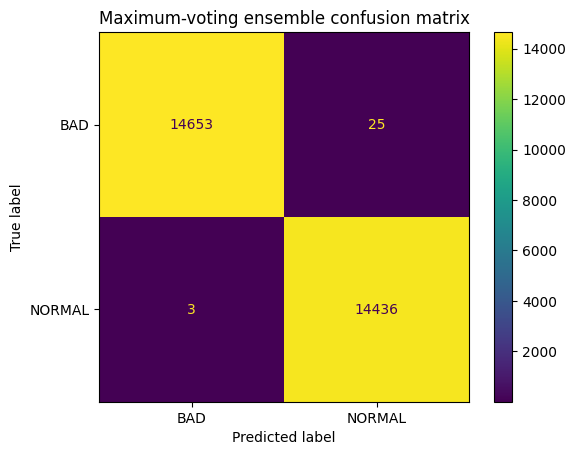

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

confusion_display = ConfusionMatrixDisplay(
    confusion_matrix=ensemble_matrix,
    display_labels=[
        "BAD",
        "NORMAL",
    ],
)

confusion_display.plot(
    values_format="d",
)

plt.title(
    "Maximum-voting ensemble confusion matrix"
)
plt.show()